In [1]:
name = "circle36"

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import os
from IPython.display import display_markdown as md
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import date

DB_FILE = name+".db"
#DB_FILE_ro = name+".db"
DB_FILE_ro = "file:"+name+".db?mode=ro"

In [3]:
conn = sqlite3.connect(DB_FILE_ro, uri=True)
query_metadata = """
SELECT id, startDate, completionDate, computerName, size, rs, eta, prefactors, T_bot, T_top, temperature_description, number_of_rounds, allgather_time 
FROM _experiments 
ORDER BY startDate DESC 
LIMIT 1
"""
df_exp = pd.read_sql_query(query_metadata, conn)
experimentID = int(df_exp['id'].iloc[0])#df_exp is one row so iloc[0], for last row of query df_exp use iloc[-1]
size = df_exp['size'].iloc[0]
overlapRatio = df_exp['rs'].iloc[0]
eta = df_exp['eta'].iloc[0]
prefactors = list(map(float,df_exp['prefactors'].iloc[0][1:-1:].split(',')))
T_bot = df_exp['T_bot'].iloc[0]
T_top = df_exp['T_top'].iloc[0]
temperature_description = df_exp['temperature_description'].iloc[0]
number_of_rounds = df_exp['number_of_rounds'].iloc[0]
seconds_between_rounds = df_exp['allgather_time'].iloc[0]
startDate = df_exp['startDate'].iloc[0]
completionDate = df_exp['completionDate'].iloc[0]
if temperature_description =='linear':
    temp_of_bin = lambda i : round(T_bot + ((T_top - T_bot)/size)*i, 6)
    temperature_description_string = ' temperature intervals are discretised linearly into '+str(size)+' bins'
elif temperature_description =='geometric':
    temp_of_bin = lambda i : round(T_bot*pow((T_top/T_bot), i/(size-1)), 6)
    temperature_description_string = ' temperature intervals are discretised geometrically into '+str(size)+' bins'
else:
    temperature_description_string = '... \n\n Wrong notebook for temp scan!!! Evaluate the experiment with the notebook *evaluate_temperature_scan.ipynb*.'

#initial Config data ---> taken from first frame of rank 0
cur = conn.cursor()
cur.execute("""SELECT * FROM _experiments_all_curves WHERE experimentID = ? AND frameNumber = 1 AND rankNumber = 0 """, (experimentID,))
row = cur.fetchone()
edgeLength = row[8]
curveLength =  row[7]
sphereCount = row[9]
reachConstraint = row[10]
cur.execute("""SELECT inputSphereRadius FROM _measures WHERE curveID = ?""", (row[0], ))
inputSphereRadius = cur.fetchone()[0]

MARKDOWN='''## Experimenting with '''+name+''' experiment id $='''+str(experimentID)+'''$

- $r_{s} = '''+str(overlapRatio)+'''$, and  $\\eta ='''+str(eta)+'''$ with input sphere $R(1 + r_{s}^{*}) = '''+str(inputSphereRadius)+'''$, and embedded tube radius $'''+str(reachConstraint)+'''$ the curve is interpolated with '''+str(sphereCount)+''' balls with (fixed) approximate edge length $dl='''+str(edgeLength)+'''$.

- Coefficients are $\\alpha_{0} = '''+str(prefactors[0])+'''$, $\\alpha_{1} = '''+str(prefactors[1])+'''$, $\\alpha_{2} = '''+str(prefactors[2])+'''$, $\\alpha_{3} = '''+str(prefactors[3])+'''$

- Computing over '''+str(size)+''' systems  with temperature $T\in['''+str(T_bot)+''','''+str(T_top)+''']$, '''+temperature_description_string+'''.

- Each round lasting '''+str(seconds_between_rounds)+''' seconds for '''+str(number_of_rounds)+''' rounds.

- Experiment computed for '''+str(round((number_of_rounds*seconds_between_rounds)/(60*60*24), 3))+''' days.'''
md(MARKDOWN, raw=True)

## Experimenting with circle36 experiment id $=55$

- $r_{s} = 0.1$, and  $\eta =0.05$ with input sphere $R(1 + r_{s}^{*}) = 1.10856$, and embedded tube radius $143$ the curve is interpolated with 0.25 balls with (fixed) approximate edge length $dl=35.75$.

- Coefficients are $\alpha_{0} = 59.95606$, $\alpha_{1} = -0.45881$, $\alpha_{2} = 0.00595$, $\alpha_{3} = 0.0007$

- Computing over 10 systems  with temperature $T\in[0.001,0.1]$,  temperature intervals are discretised linearly into 10 bins.

- Each round lasting 1200.0 seconds for 3 rounds.

- Experiment computed for 0.042 days.

In [4]:
startDate_readable = (lambda d: f"{d.day}{'th' if 11<=d.day%100<=13 else {1:'st',2:'nd',3:'rd'}.get(d.day%10,'th')} {d.strftime('%B')}")(datetime.strptime(startDate, "%d/%m/%Y/%H/%M/%S"))
print("experiment started", startDate_readable, "script evaluated", date.today().strftime("%B %d, %Y"))

experiment started 31st July script evaluated August 03, 2026


In [5]:
def parse_time(s):
    return datetime.strptime(s, '%d/%m/%Y/%H/%M/%S').timestamp()

start_time_seconds = parse_time(startDate)

In [6]:
#normalised_energy = float(line[18]) # (E - E_0)/L
def compute_normalised_energy(V, A, C, X, V_0, A_0, C_0, X_0, L):
    return (prefactors[0]*(V - V_0) + prefactors[1]*(A - A_0) + prefactors[2]*(C - C_0) + prefactors[3]*(X - X_0))/L
        

In [7]:
query_curves = f"""
SELECT id, frameNumber, rankNumber, temperature, energy, time_in_sequence, L
FROM _experiments_all_curves 
WHERE experimentID = {experimentID}
ORDER BY rankNumber, frameNumber
"""
df_curves = pd.read_sql_query(query_curves, conn)
curve_ids_str = ",".join(map(str, df_curves['id'].unique()))

query_measures = f"""
SELECT id, curveID, V0, V, A0, A, C0, C, X0, X FROM _measures 
WHERE curveID IN ({curve_ids_str})
"""
df_measures = pd.read_sql_query(query_measures, conn)

query_experiment_stats = f"""
SELECT * FROM _experiment_stats 
WHERE experimentID IN ({experimentID})
"""
df_exp_stats = pd.read_sql_query(query_experiment_stats, conn)

query_experimet_stats_intra_rounds = f"""
SELECT * FROM _experiment_stats_intra_rounds
WHERE curveID IN ({curve_ids_str})
"""
df_exp_stats_intra_rounds = pd.read_sql_query(query_experimet_stats_intra_rounds, conn)    

In [8]:
df_exp_stats_intra_rounds.head()

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round
0,1,1,0,0,0.001,1.000,0.00000,1,-5.987075,0,0.006720,0,0
1,2,2,0,1738,0.001,3.606,-0.04585,0,-6.067815,0,273.699250,0,1738
2,3,3,0,3504,0.001,1.231,-0.00742,0,-6.095628,0,551.601833,0,3504
3,4,4,0,5285,0.001,0.000,0.37709,0,-6.086472,0,835.861915,0,5285
4,5,5,0,7032,0.001,0.000,3.99255,0,-6.114928,0,1122.369781,0,7032


In [9]:
df_exp_stats.head()

,id,experimentID,round_nbr,temperatures,prob,acceptOrNot,binIndices,energy
0,1,55,0,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0,1 1 1 1 1 1 1 1 1 1,1 0 3 2 5 4 7 6 9 8,-6.0981 -5.4674 -4.7513 -4.3804 -4.1295 -1.366...
1,2,55,1,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 -1.0 1.0 1.0 1.0 1.0 1.0 1.0 -1.0 1.0,1 -1 1 1 1 1 1 1 -1 1,2 0 4 1 6 3 8 5 9 7,-5.4503 -5.9018 -4.2031 -4.6052 -1.7276 -1.294...
2,3,55,2,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0,1 1 1 1 1 1 1 1 1 1,3 1 5 0 7 2 9 4 8 6,-4.6897 -5.9363 -3.9528 -5.047 -0.1944 -1.7983...


In [10]:
df_exp_stats.tail()

,id,experimentID,round_nbr,temperatures,prob,acceptOrNot,binIndices,energy
0,1,55,0,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0,1 1 1 1 1 1 1 1 1 1,1 0 3 2 5 4 7 6 9 8,-6.0981 -5.4674 -4.7513 -4.3804 -4.1295 -1.366...
1,2,55,1,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 -1.0 1.0 1.0 1.0 1.0 1.0 1.0 -1.0 1.0,1 -1 1 1 1 1 1 1 -1 1,2 0 4 1 6 3 8 5 9 7,-5.4503 -5.9018 -4.2031 -4.6052 -1.7276 -1.294...
2,3,55,2,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0,1 1 1 1 1 1 1 1 1 1,3 1 5 0 7 2 9 4 8 6,-4.6897 -5.9363 -3.9528 -5.047 -0.1944 -1.7983...


In [11]:
df_curves.head()

,id,frameNumber,rankNumber,temperature,energy,time_in_sequence,L
0,1,1,0,0.001,-5.987075,0.006720,35.75
1,2,2,0,0.001,-6.067815,273.699250,35.75
2,3,3,0,0.001,-6.095628,551.601833,35.75
3,4,4,0,0.001,-6.086472,835.861915,35.75
4,5,5,0,0.001,-6.114928,1122.369781,35.75


In [12]:
#check temperatures
#print(df_exp_stats["temperatures"].iloc[0].strip().split(' '))

temperatures = list(map(float, df_exp_stats["temperatures"].iloc[0].strip().split(' ')))
dic_temps = dict(enumerate(temperatures))
return_bin_index = lambda T: next(k for k, v in dic_temps.items() if v == T)
for i in range(size):
    print(i, temperatures[i], return_bin_index(temperatures[i]))

0 0.001 0
1 0.0109 1
2 0.0208 2
3 0.0307 3
4 0.0406 4
5 0.0505 5
6 0.0604 6
7 0.0703 7
8 0.0802 8
9 0.0901 9


For a systems of size $n$ one expects if $i$ is even and $n$ is even then maximally
- $i$ climbs the temperature ladder every proposed round becuase the parity of $i$ is the same as the round number
- $i$ needs $n-i$ steps to get to $n$ and $n-i$ steps to get back
- if $i=0$ then we need $n - 1$ to get to $n-1$ and $n-1$ to get back --> at least $2(n-1)$ for a single round trip.

Next is a guess: If each edge has probability $p$ of being traversed, then the total round trip time is $2(n-1)\frac{1}{p}$ and $(n-1)\frac{1}{p}$ for half trip times.


In [13]:
def parse_space_string(s, dtype=int):
    return np.array(s.split(), dtype=dtype)
# shape: (n_rounds, n_ranks)
# traj[r, i] = which temperature bin rank i occupies at round r
traj = np.vstack(df_exp_stats['binIndices'].apply(parse_space_string).values)  # (n_rounds, n_ranks)
initial_row = np.arange(size).reshape(1, size)
traj = np.vstack([initial_row, traj])
temps = parse_space_string(df_exp_stats['temperatures'].iloc[0], dtype=float)   # (n_ranks,)

print(f"Rounds: {number_of_rounds}, Size: {size}")
print(f"Temperature ladder: {temps}")
print(f"Trajectory matrix shape: {traj.shape}")
print(f"\nFirst 3 rows of traj:\n{traj[:3]}")

Rounds: 3, Size: 10
Temperature ladder: [0.001  0.0109 0.0208 0.0307 0.0406 0.0505 0.0604 0.0703 0.0802 0.0901]
Trajectory matrix shape: (4, 10)

First 3 rows of traj:
[[0 1 2 3 4 5 6 7 8 9]
 [1 0 3 2 5 4 7 6 9 8]
 [2 0 4 1 6 3 8 5 9 7]]


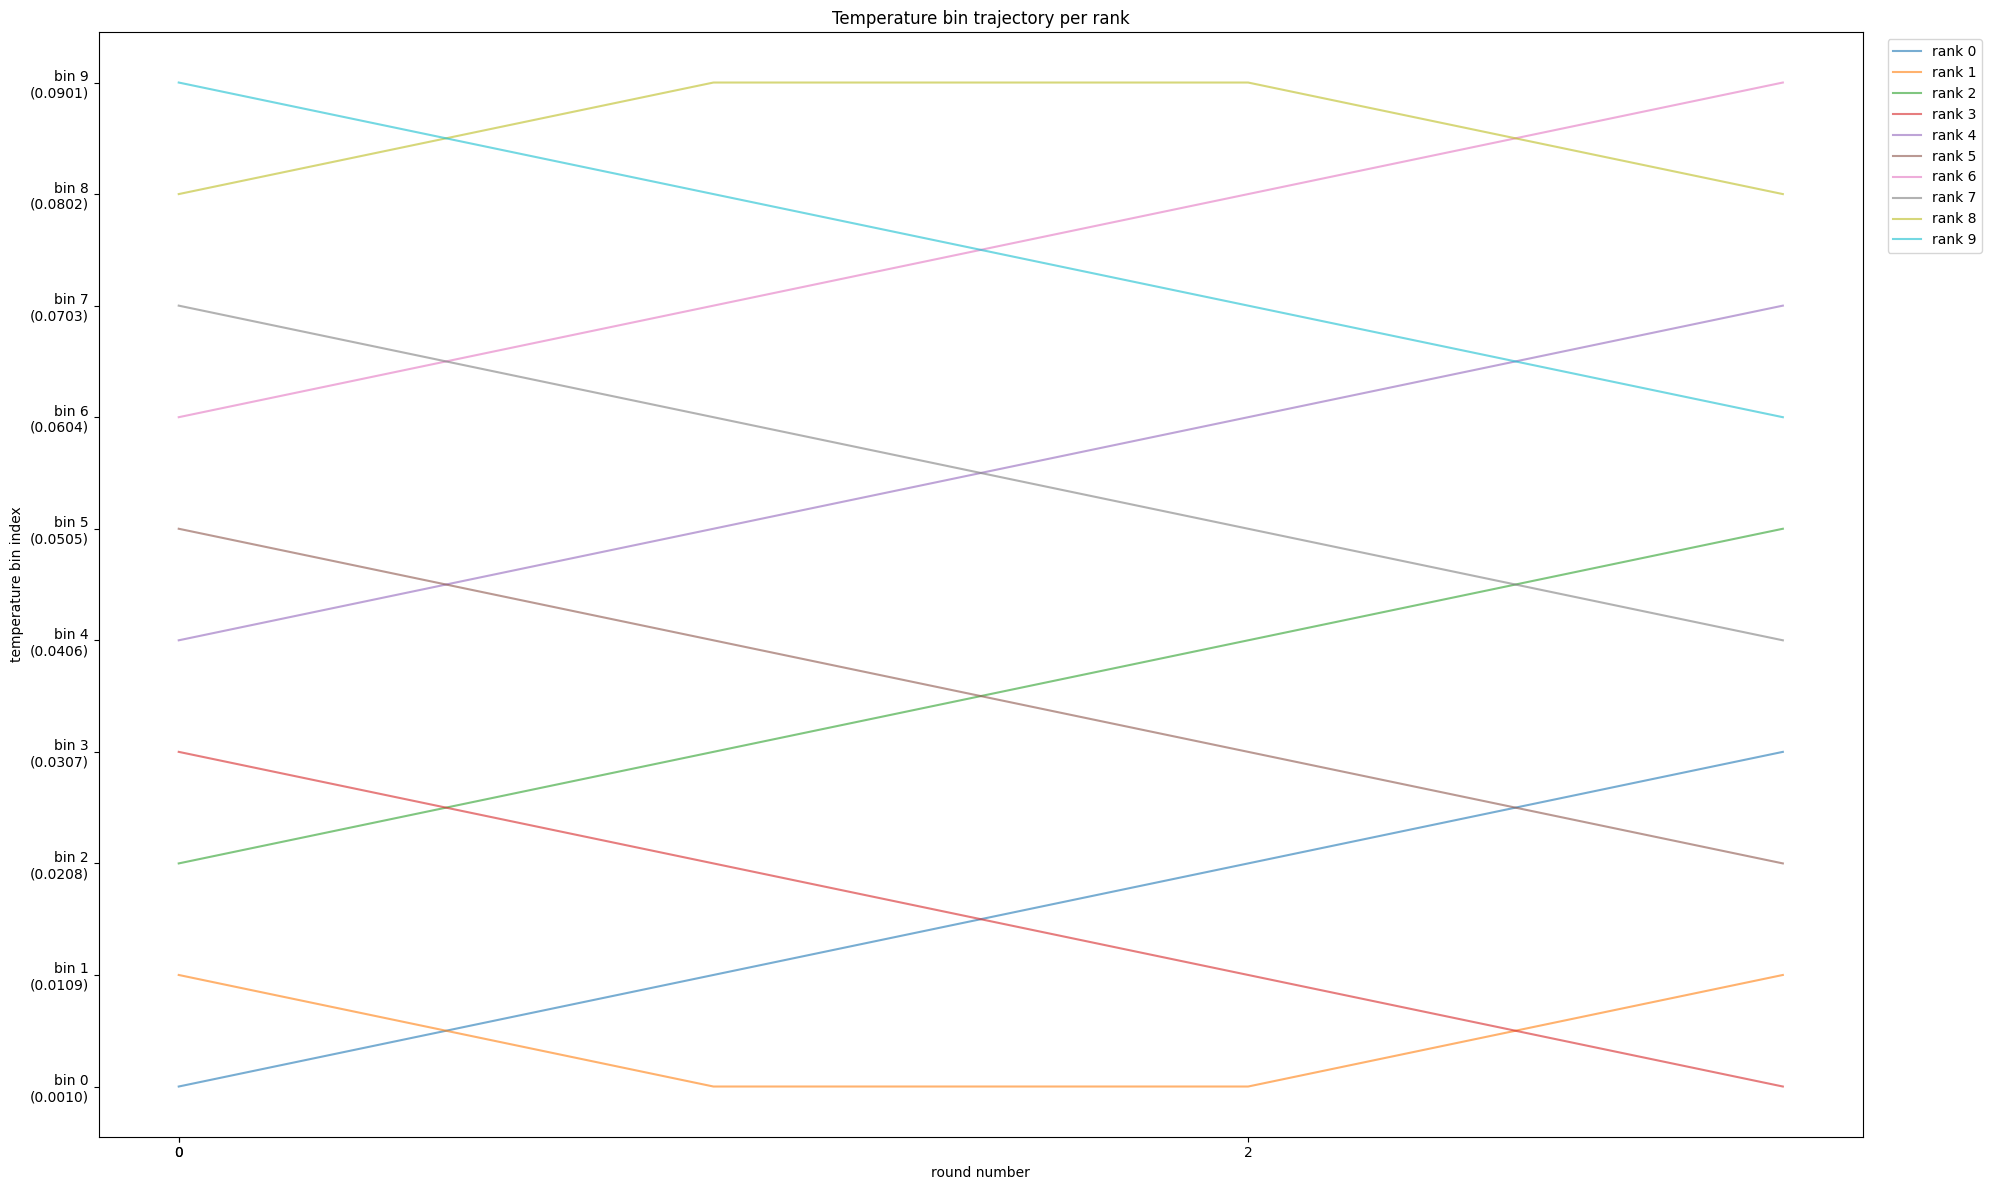

In [14]:
fig, ax = plt.subplots(figsize=(20, 12))

cmap = plt.get_cmap('tab10', size)

for i in range(size):
    ax.plot(
        np.arange(number_of_rounds+1),
        traj[:, i],
        color=cmap(i),
        label=f'rank {i}',
        alpha=0.6,
    )

#tofu fix the tick number at the moment the count is change after round round nbr so the first change  is at the end of round 0
ax.set_xlabel('round number')
tick_positions = [0] + list(range(0, number_of_rounds+1, 2))
tick_labels = ['start'] + list(range(0, number_of_rounds+1, 2))
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_ylabel('temperature bin index')
ax.set_yticks(range(size))
ax.set_yticklabels([f'bin {j}\n({temps[j]:.4f})' for j in range(size)])
ax.set_title('Temperature bin trajectory per rank')
ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
#fig.savefig("trajectory.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
def round_trip_stats(traj):
    for i in range(size):
        # traj[r, i] = which temperature bin rank i occupies at round r
        path = traj[:, i]
        
        # rounds to first reach top bin
        top_visits = np.where(path == size - 1)[0]
        #print(top_visits)
        rounds_to_top = top_visits[0] if len(top_visits) > 0 else None
        
        # round trips: top -> bottom -> top
        trips = 0
        trip_lengths = []
        at_top = False
        top_round = None
        
        for k in range(number_of_rounds + 1):
            if path[k] == size - 1 and not at_top:
                at_top = True
                top_round = k
            elif path[k] == 0 and at_top:
                at_top = False
                trips += 1
                trip_lengths.append(k - top_round)
        
        top_str = f"{rounds_to_top}" if rounds_to_top is not None else "never"
        if trips > 0:
            print(f"Rank {i}: rounds to top bin: {top_str}, round trips: {trips}, avg {np.mean(trip_lengths):.1f} rounds per trip")
        else:
            print(f"Rank {i}: rounds to top bin: {top_str}, round trips: 0")


round_trip_stats(traj)
print("\n Total number of rounds is ", number_of_rounds)

Rank 0: rounds to top bin: never, round trips: 0
Rank 1: rounds to top bin: never, round trips: 0
Rank 2: rounds to top bin: never, round trips: 0
Rank 3: rounds to top bin: never, round trips: 0
Rank 4: rounds to top bin: never, round trips: 0
Rank 5: rounds to top bin: never, round trips: 0
Rank 6: rounds to top bin: 3, round trips: 0
Rank 7: rounds to top bin: never, round trips: 0
Rank 8: rounds to top bin: 1, round trips: 0
Rank 9: rounds to top bin: 0, round trips: 0

 Total number of rounds is  3


In [16]:
visits_tally=np.zeros(size)
bin_list_round_k = np.arange(size)
for k in range(number_of_rounds-1):
    tmp = df_exp_stats[df_exp_stats["round_nbr"]==k]['binIndices'].apply(parse_space_string).values[0]
    #print(k, bin_list_round_k, tmp, "\n")
    for b in range(size):
        if np.where(bin_list_round_k == b)[0] != np.where(tmp == b)[0]:
            visits_tally[b]+=1
    bin_list_round_k = tmp
for b in range(size):
    print(f"Bin {b}: total of {visits_tally[b]}\n")


Bin 0: total of 1.0

Bin 1: total of 2.0

Bin 2: total of 2.0

Bin 3: total of 2.0

Bin 4: total of 2.0

Bin 5: total of 2.0

Bin 6: total of 2.0

Bin 7: total of 2.0

Bin 8: total of 2.0

Bin 9: total of 1.0



In [17]:
energies = np.vstack(df_exp_stats['energy'].apply(lambda s: parse_space_string(s, dtype=float)).values)
#energies[10] # energy after round 10 on each rank

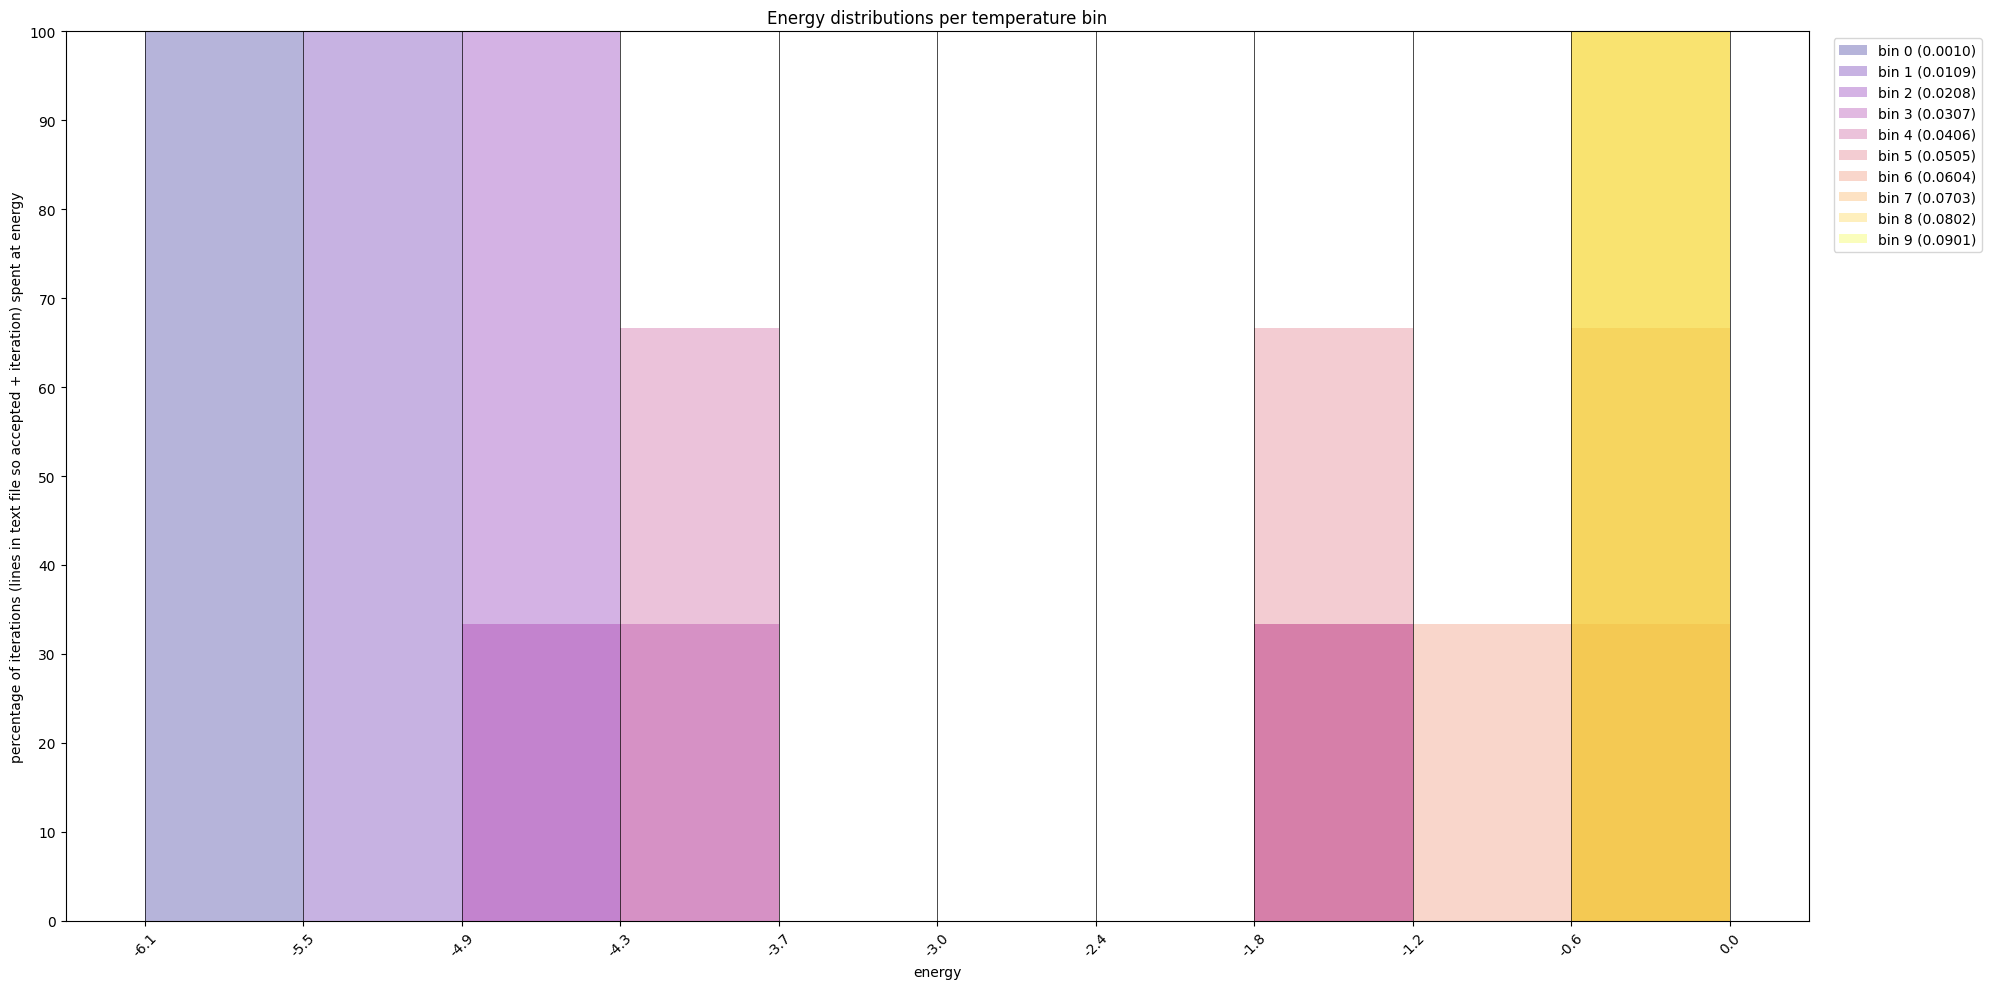

In [18]:
# for each bin, collect all energies sampled there across all rounds and ranks
n_bins = size
bin_energies = {b: [] for b in range(n_bins)}

for r in range(number_of_rounds):
    for i in range(size):
        b = traj[r, i]  # which bin rank i is at in round r
        bin_energies[b].append(energies[r, i])

#compute the energy bin sizes from the minimum energy value
n_bins_histogram = 10
E_min = min(e for energies in bin_energies.values() for e in energies)
E_max = 0.0  # flat region
bin_width = (E_max - E_min) / n_bins_histogram
bin_edges = np.linspace(E_min, E_max, n_bins_histogram + 1)

# plot
fig, ax = plt.subplots(figsize=(20, 10))

cmap = plt.get_cmap('plasma', n_bins)

for b in range(n_bins):
    ax.hist(
        bin_energies[b],
        bins=bin_edges,
        edgecolor='none',
        alpha=0.3,
        color=cmap(b),
        label=f'bin {b} ({temps[b]:.4f})',
        density=False,
        weights=np.ones(len(bin_energies[b])) / len(bin_energies[b]) * 100,
    )

# add vertical lines at each separation edge between bins
for edge in bin_edges:
    ax.axvline(x=edge, color='black', linewidth=0.5)

ax.set_xlabel('energy')
ax.set_xticks(bin_edges)
ax.set_xticklabels([f'{e:.1f}' for e in bin_edges], rotation=45)
#ax.set_yscale('log')
ax.set_yticks(range(0, 101, 10))
ax.set_ylim(0, 100)
ax.set_ylabel('percentage of iterations (lines in text file so accepted + iteration) spent at energy')
ax.set_title('Energy distributions per temperature bin')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
#fig.savefig('energy_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

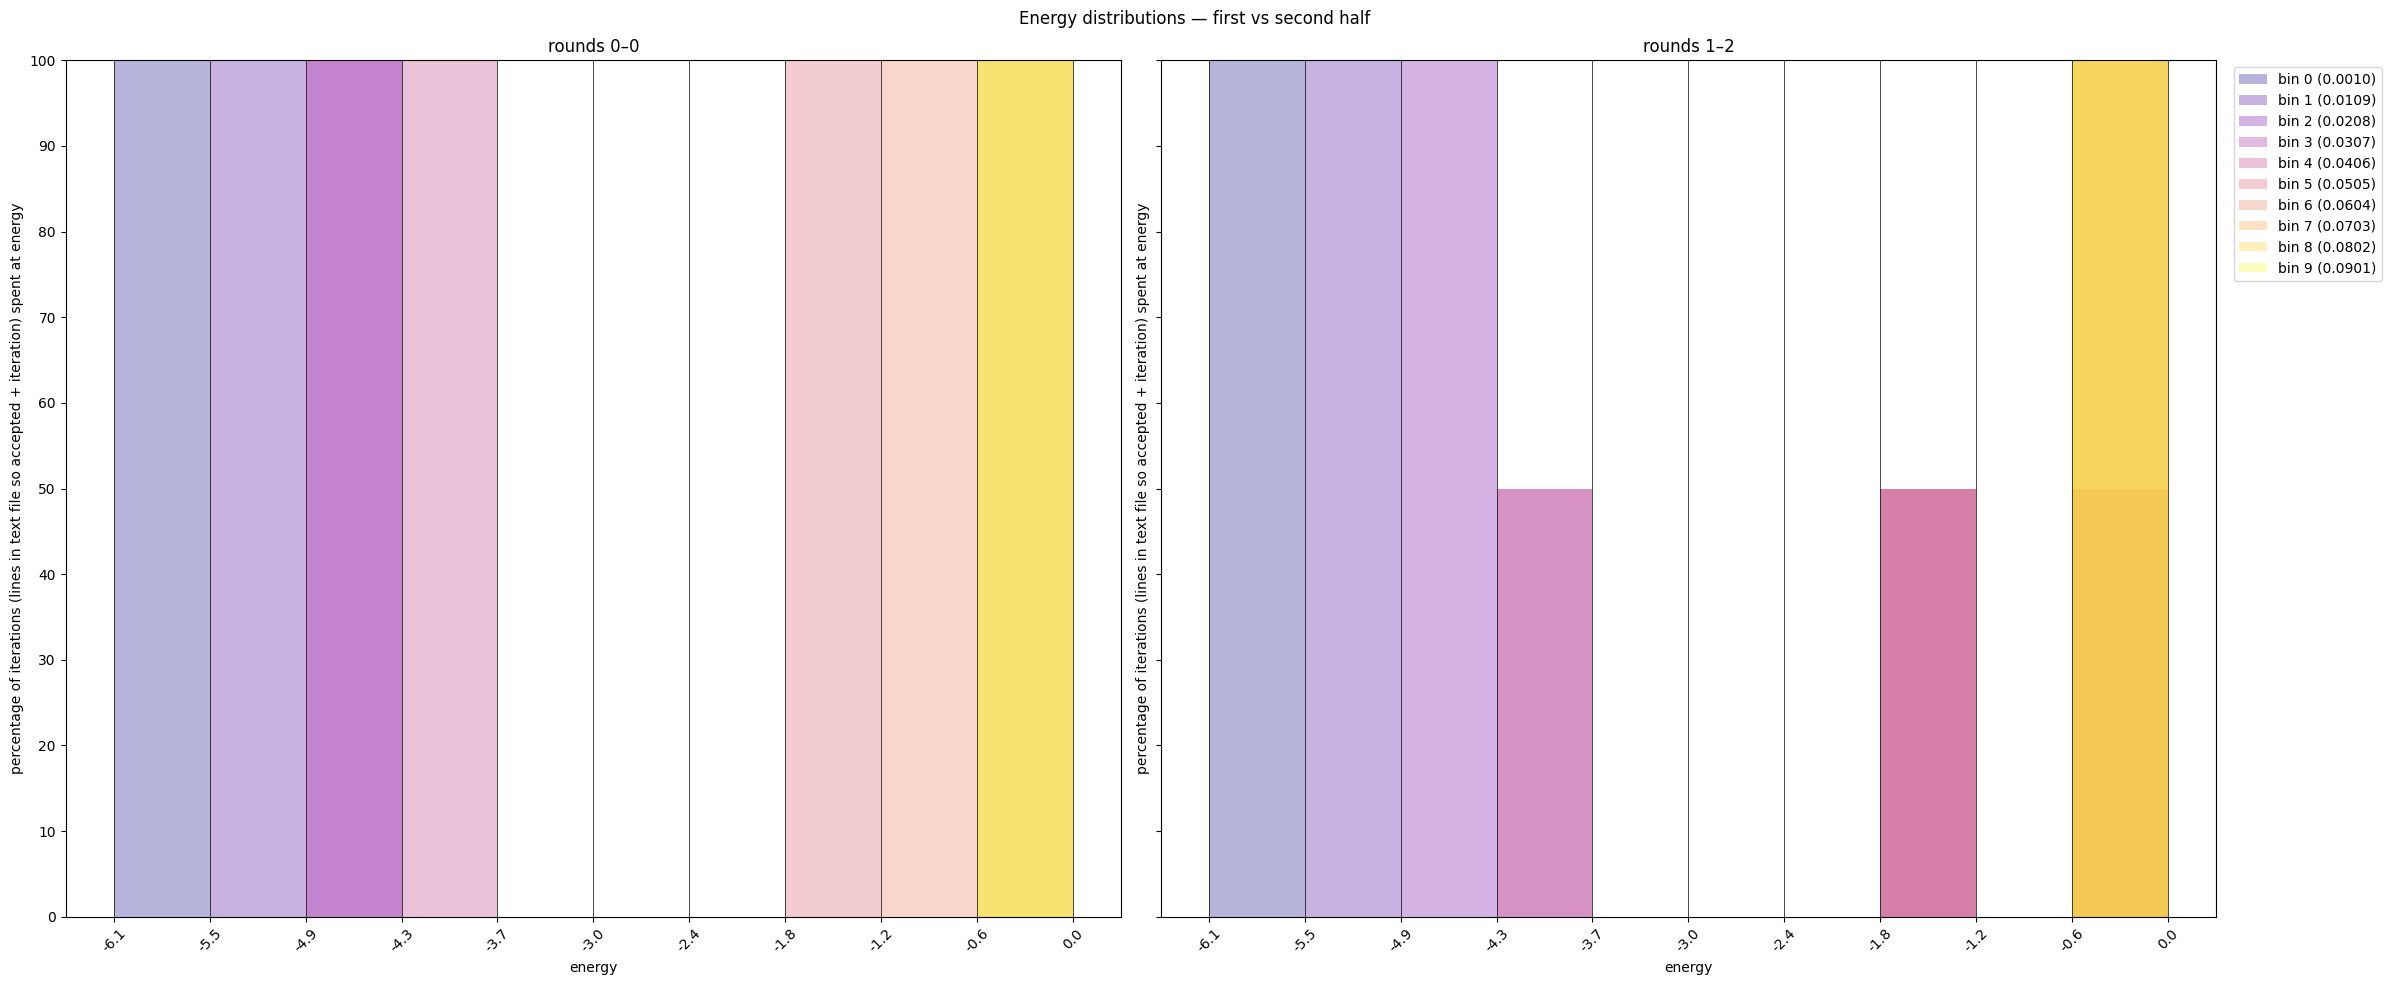

In [19]:
mid =number_of_rounds // 2

fig, axes = plt.subplots(1, 2, figsize=(24, 10), sharey=True)

for ax, (start, end), label in zip(
    axes,
    [(0, mid), (mid, number_of_rounds)],
    [f'rounds 0–{mid-1}', f'rounds {mid}–{number_of_rounds-1}']
):
    bin_energies = {b: [] for b in range(size)}
    for r in range(start, end):
        for i in range(size):
            b = traj[r, i]
            bin_energies[b].append(energies[r, i])

    for b in range(size):
        ax.hist(
            bin_energies[b],
            bins=bin_edges,
            alpha=0.3,
            edgecolor='none',
            linewidth=0,
            color=cmap(b),
            label=f'bin {b} ({temps[b]:.4f})',
            density=False,
            weights=np.ones(len(bin_energies[b])) / len(bin_energies[b]) * 100,
        )
    for edge in bin_edges:
        ax.axvline(x=edge, color='black', linewidth=0.5)

    ax.set_xticks(bin_edges)
    ax.set_xticklabels([f'{e:.1f}' for e in bin_edges], rotation=45)
    ax.set_xlabel('energy')
    ax.set_yticks(range(0, 101, 10))
    ax.set_ylim(0, 100)
    ax.set_ylabel('percentage of iterations (lines in text file so accepted + iteration) spent at energy')
    ax.set_title(label)
    
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.suptitle('Energy distributions — first vs second half')
plt.tight_layout()
#fig.savefig('energy_distributions_halves.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                             name
0                    _experiments
1                 sqlite_sequence
2         _experiments_all_curves
3                       _measures
4               _experiment_stats
5  _experiment_stats_intra_rounds


In [21]:
df_curves[::200].head(4)

,id,frameNumber,rankNumber,temperature,energy,time_in_sequence,L
0,1,1,0,0.0010,-5.987075,0.006720,35.75
200,201,36,9,0.0703,-0.000090,3272.563276,35.75


In [22]:
df_measures[::200].head(4)

,id,curveID,V0,V,A0,A,C0,C,X0,X
0,1,1,137.4358,133.3948,249.009,186.3317,112.7904,24.5366,0.0,12.5664
200,201,201,137.4358,137.4357,249.009,249.0065,112.7904,112.7881,0.0,0.0000


In [23]:
df_curves.iloc[0]

id                   1.000000
frameNumber          1.000000
rankNumber           0.000000
temperature          0.001000
energy              -5.987075
time_in_sequence     0.006720
L                   35.750000
Name: 0, dtype: float64

In [24]:
df_exp_stats_intra_rounds.iloc[0]

id                   1.000000
curveID              1.000000
rank                 0.000000
it_no                0.000000
T                    0.001000
prob                 1.000000
deltaE               0.000000
accept               1.000000
energy              -5.987075
bin_index            0.000000
time                 0.006720
round_nbr            0.000000
it_no_intra_round    0.000000
Name: 0, dtype: float64

In [25]:
df_exp_stats_intra_rounds.head(10)

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round
0,1,1,0,0,0.0010,1.000,0.00000,1,-5.987075,0,0.006720,0,0
1,2,2,0,1738,0.0010,3.606,-0.04585,0,-6.067815,0,273.699250,0,1738
2,3,3,0,3504,0.0010,1.231,-0.00742,0,-6.095628,0,551.601833,0,3504
3,4,4,0,5285,0.0010,0.000,0.37709,0,-6.086472,0,835.861915,0,5285
4,5,5,0,7032,0.0010,0.000,3.99255,0,-6.114928,0,1122.369781,0,7032
5,6,6,0,7854,0.0109,0.000,5.74697,0,-5.916933,1,1258.971605,1,355
6,7,7,0,9263,0.0109,0.495,0.27420,0,-5.738210,1,1472.239943,1,1764
7,8,8,0,10652,0.0109,1.477,-0.15202,0,-5.603647,1,1687.130668,1,3153
8,9,9,0,13410,0.0109,0.000,3.28507,0,-5.483049,1,2098.607356,1,5911
9,10,10,0,14813,0.0109,0.001,2.62110,0,-5.407420,1,2311.058331,1,7314


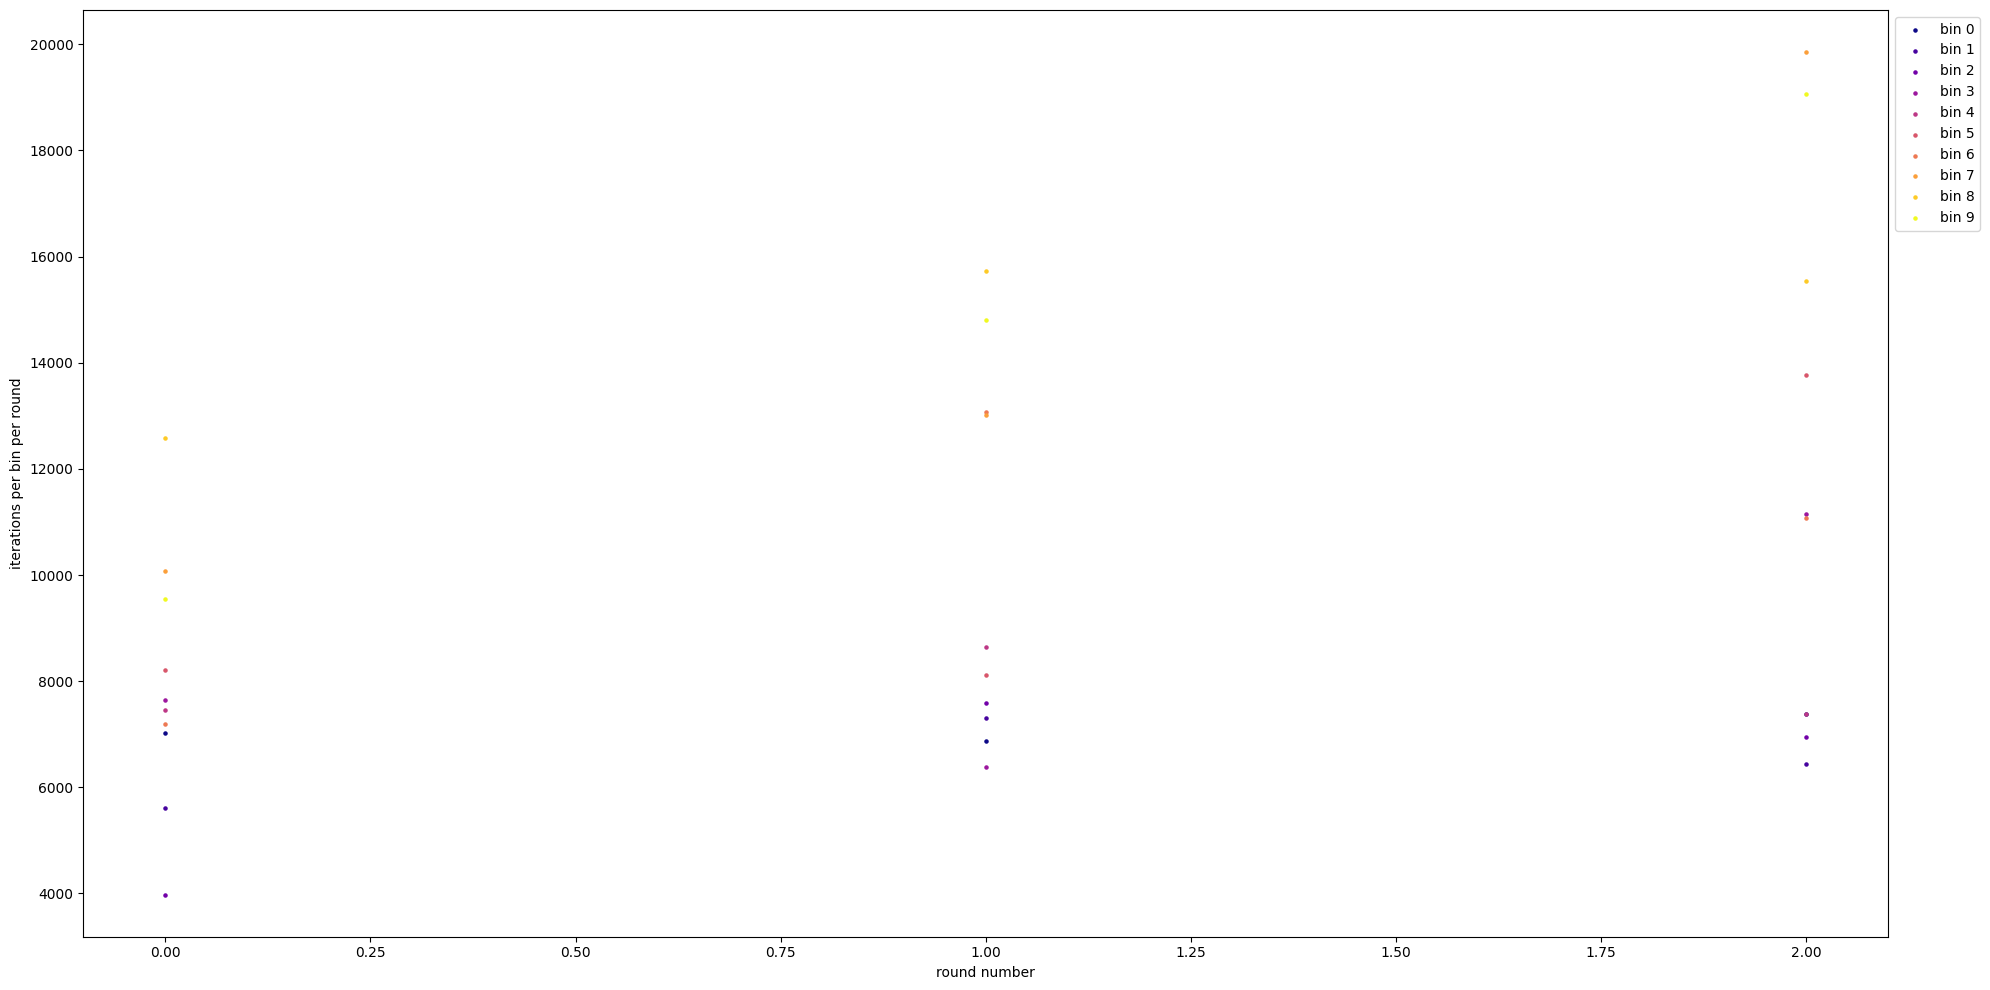

In [26]:
data_entries_generated_per_bin_round = (df_exp_stats_intra_rounds
    .groupby(['round_nbr', 'bin_index'])
    .size()
    .reset_index(name='n_iterations')
)

iterations_per_bin_round = (df_exp_stats_intra_rounds
    .groupby(['round_nbr', 'bin_index'])['it_no_intra_round']
    .max()
    .reset_index(name='max_iteration')
)


fig, ax = plt.subplots(figsize=(20, 10))
cmap = plt.get_cmap('plasma', size)
for b in range(size):
    data = iterations_per_bin_round[iterations_per_bin_round['bin_index'] == b]
    ax.scatter(data['round_nbr'], data['max_iteration'], s=5, color=cmap(b), label=f'bin {b}')
    #data = data_entries_generated_per_bin_round[data_entries_generated_per_bin_round['bin_index'] == b]
    #ax.scatter(data['round_nbr'], data['n_iterations'], s=5, color=cmap(b), label=f'bin {b}')

ax.set_xlabel('round number')
ax.set_ylabel('iterations per bin per round')
ax.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.tight_layout()
#fig.savefig(f'number_iterations_per_round.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
curve_to_round = df_exp_stats_intra_rounds.drop_duplicates('curveID').set_index('curveID')['round_nbr']
df_curves['round_nbr'] = df_curves['id'].map(curve_to_round)

In [28]:
def assign_bin_index(T, dic_temps):
    for ind, t in dic_temps.items():
        if abs(T - t) < 0.0001:
            return ind
    return None

df_curves['bin_index'] = df_curves['temperature'].apply(
    lambda t: assign_bin_index(t, dic_temps)
)
# check
print(df_curves[['id', 'rankNumber', 'time_in_sequence', 'round_nbr', 'bin_index', 'temperature']].head(5).to_string())
print(f"\nUnassigned rows: {df_curves['bin_index'].isna().sum()}")

   id  rankNumber  time_in_sequence  round_nbr  bin_index  temperature
0   1           0          0.006720          0          0        0.001
1   2           0        273.699250          0          0        0.001
2   3           0        551.601833          0          0        0.001
3   4           0        835.861915          0          0        0.001
4   5           0       1122.369781          0          0        0.001

Unassigned rows: 0


Now I want to plot energy distributions over the even rounds between $T_{i}$ and $T_{i+1}$ on the same graph, the probability of acceptance of that round is the title of the graph.

There are $n-1$ edges, so $\lfloor \frac{n-1}{2} \rfloor$ edges transitioning on even rounds and $n-1 - \lfloor \frac{n-1}{2} \rfloor$ on odd rounds.


In [29]:
even_rounds = df_curves[df_curves['round_nbr'] % 2 == 0]
even_rounds_intra = df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['round_nbr'] % 2 == 0]
X = 50
last_X = (even_rounds_intra
    .groupby(['round_nbr', 'rank'])
    .apply(lambda g: g.nlargest(X, 'it_no_intra_round'), include_groups=False)
    .reset_index(drop=True)
)

In [30]:
#last_X.groupby('bin_index')['energy'].count()

In [31]:
def avg_transition_prob(df_exp_stats, b, even=True, from_round=0):
    parity = 0 if even else 1
    rows = df_exp_stats[
        (df_exp_stats['round_nbr'] % 2 == parity) &
        (df_exp_stats['round_nbr'] >= from_round)
    ]
    probs = np.vstack(rows['prob'].apply(lambda s: parse_space_string(s, dtype=float)).values)
    bin_indices = np.vstack(rows['binIndices'].apply(parse_space_string).values)
    
    edge_probs = []
    for r in range(len(rows)):
        rank_at_b = np.where(bin_indices[r] == b)[0]
        if len(rank_at_b) > 0:
            edge_probs.append(probs[r, rank_at_b[0]])
    
    return round(np.mean(edge_probs), 3) if edge_probs else float('nan')

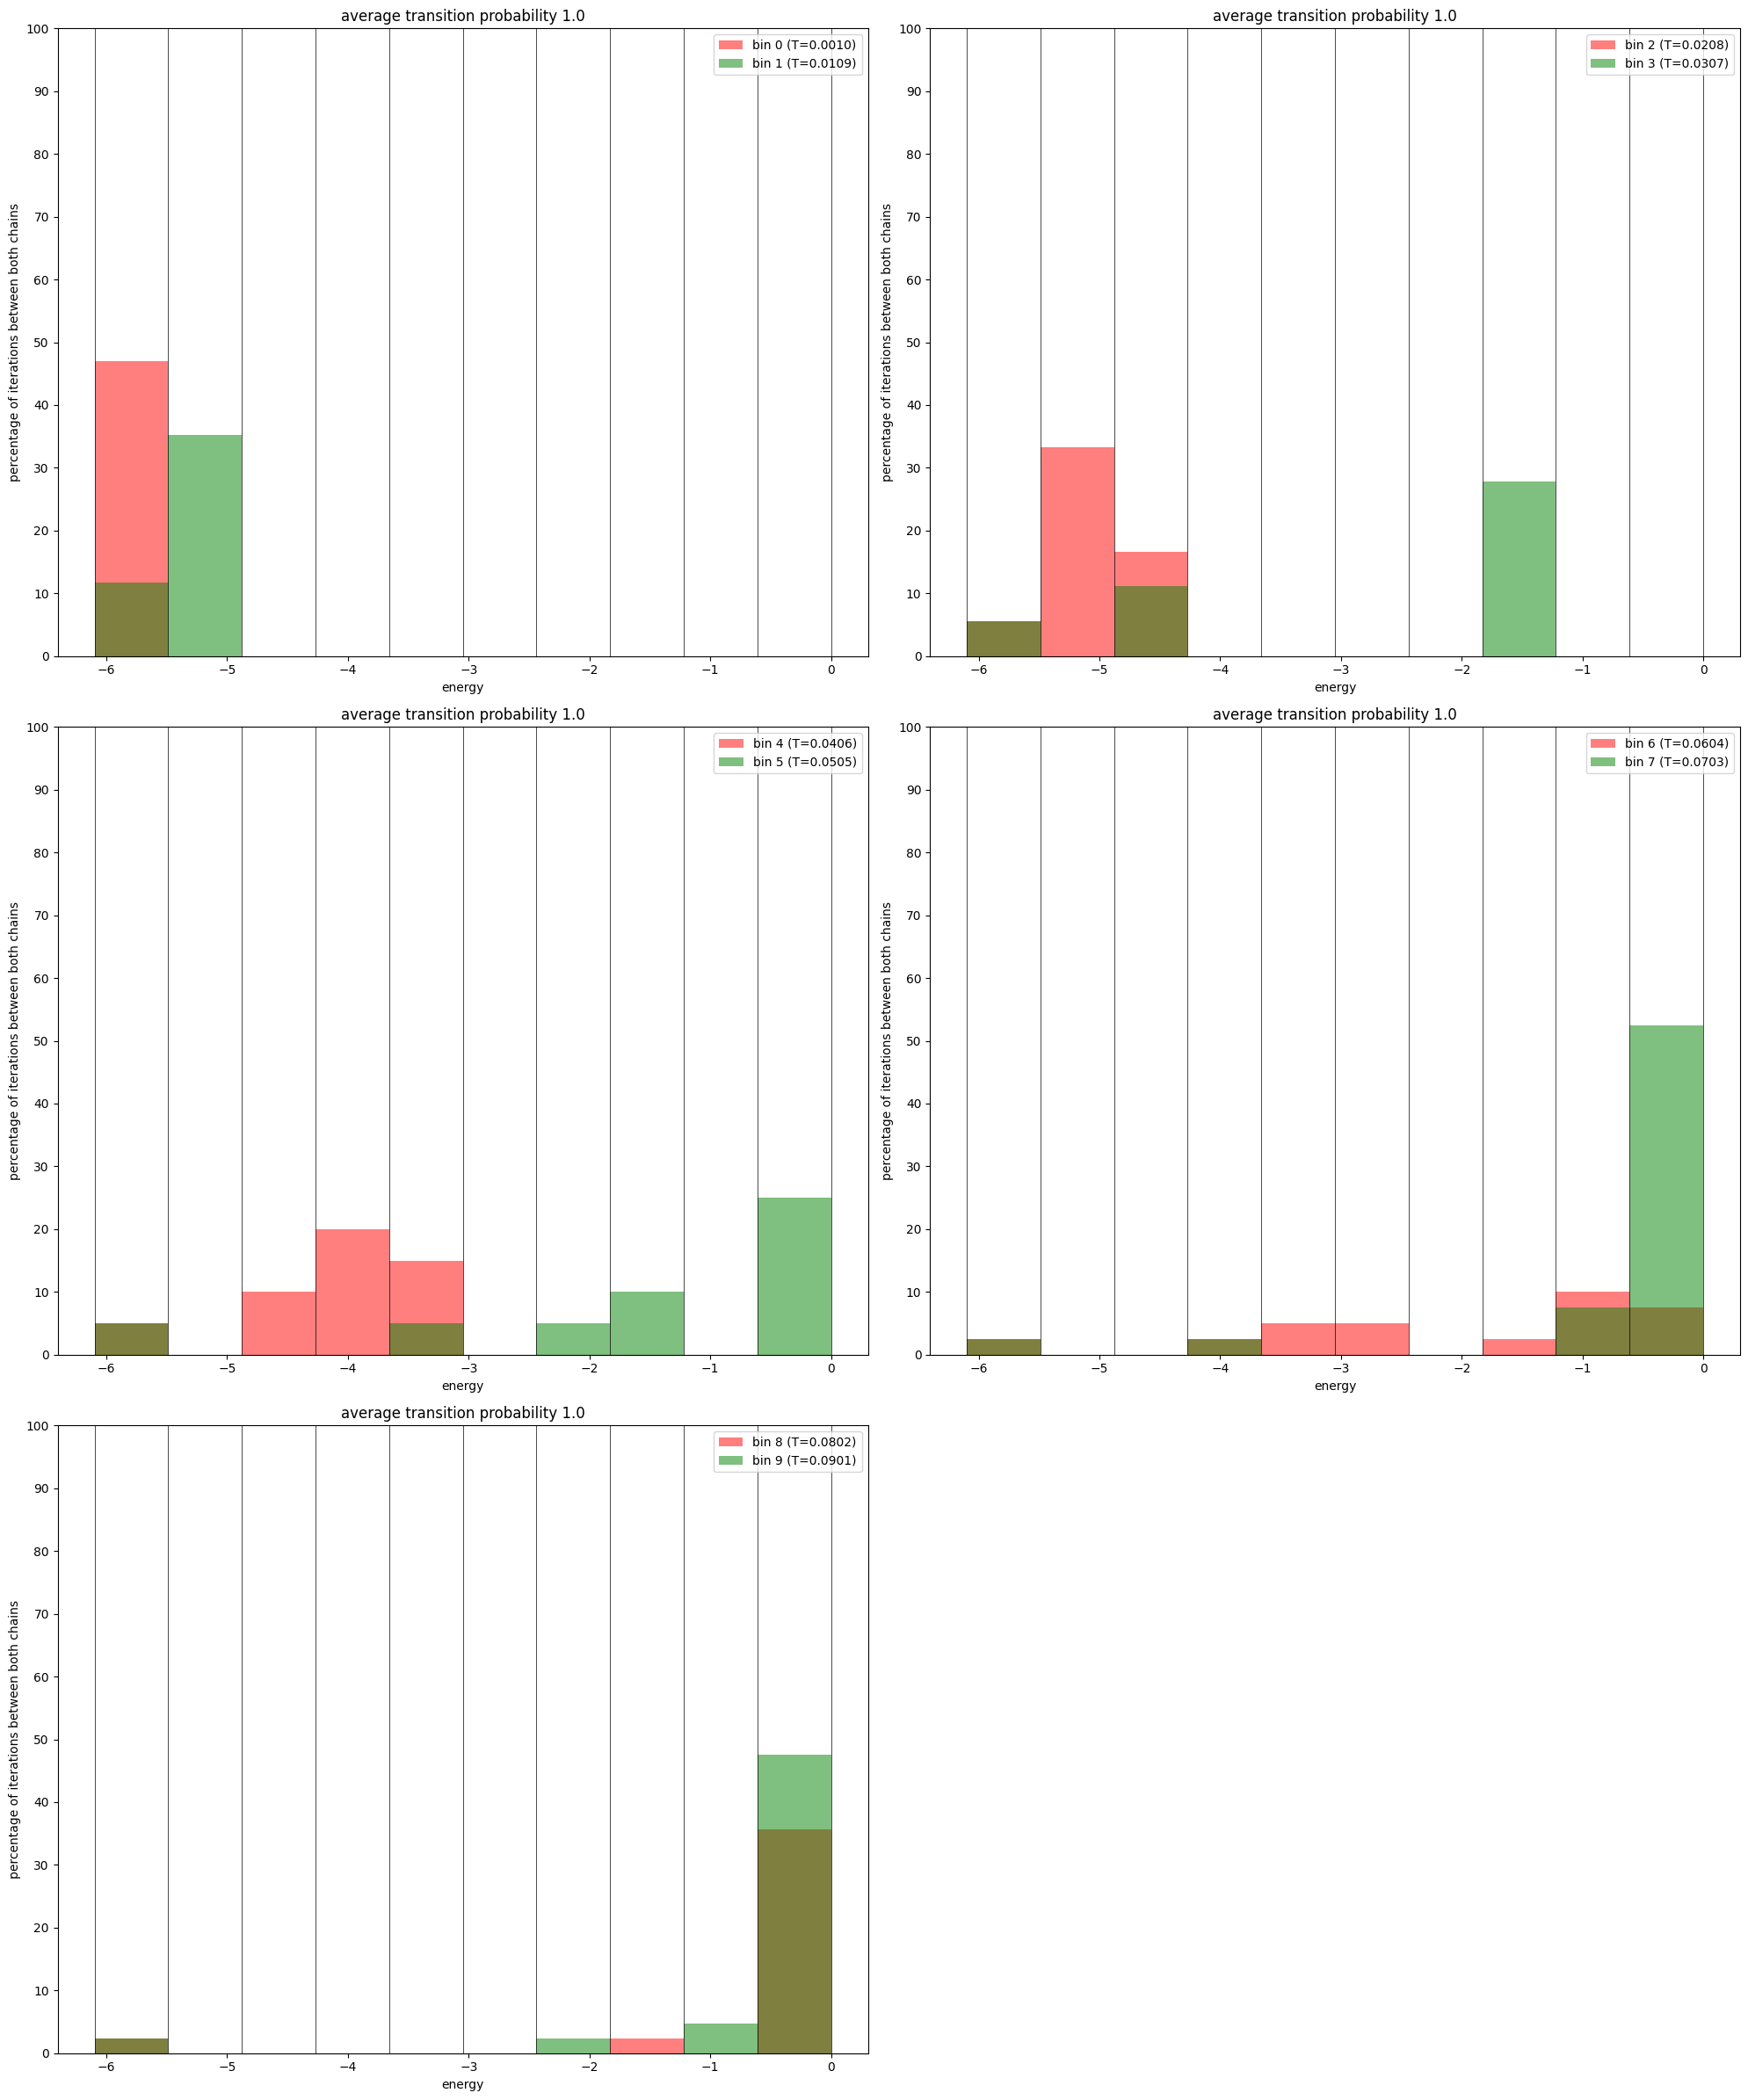

In [32]:
n_even_bins = size // 2 # pairs
ncols = 2
#nrows = n_even_bins // ncols 
nrows = -(-n_even_bins // ncols)

subplot_w, subplot_h = 10, 8   # tune once, then it scales itself
fig, axes = plt.subplots(nrows, ncols, figsize=(subplot_w * ncols, subplot_h * nrows))
axes = np.atleast_2d(axes)   # keeps axes[row][col] valid even when nrows or ncols == 1

plot_idx = 0
for b in range(size):
    if b%2==0:
        row = plot_idx // 2
        col = plot_idx % 2
        ax = axes[row][col]

        data_b = last_X[last_X['bin_index'] == b]['energy']
        data_b1 = last_X[last_X['bin_index'] == b + 1]['energy']
        #data_b = even_rounds[even_rounds['bin_index'] == b]['energy']
        #data_b1 = even_rounds[even_rounds['bin_index'] == b + 1]['energy']
        total = len(data_b) + len(data_b1)
        weights_b = np.ones(len(data_b)) / total * 100
        weights_b1 = np.ones(len(data_b1)) / total * 100
    
        # bin b
        #axes[row][col].hist(data_b, bins=10, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',weights=weights_b)
        axes[row][col].hist(data_b, bins=bin_edges, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',
                            weights=weights_b)
    
        
        # bin b+1
        axes[row][col].hist(data_b1, bins=bin_edges, density=False, alpha=0.5, color="g", label=f'bin {b+1} (T={temps[b+1]:.4f})',
                           weights=weights_b1)

        for edge in bin_edges:
            axes[row][col].axvline(x=edge, color='black', linewidth=0.5)


        axes[row][col].set_ylim(0, 100)
        axes[row][col].set_yticks(range(0, 101, 10))
        axes[row][col].set_xlabel('energy')
        axes[row][col].set_ylabel('percentage of iterations between both chains')
        axes[row][col].set_title(f'average transition probability {avg_transition_prob(df_exp_stats, b)}')
        axes[row][col].legend()
        plot_idx+=1

for idx in range(plot_idx, nrows * ncols):
    fig.delaxes(axes[idx // ncols][idx % ncols])

plt.tight_layout()
#fig.savefig(f'energy_overlap_bin{b}_{b+1}_even_rounds.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
#last_X.groupby('bin_index')['energy'].count()

Now let's repeat the above graphs for the second half of the experiment.

In [34]:
even_rounds_second_half = df_curves[(df_curves['round_nbr'] % 2 == 0 ) & (df_curves['round_nbr'] > number_of_rounds // 2 )]
even_rounds_intra_second_half = df_exp_stats_intra_rounds[(df_exp_stats_intra_rounds['round_nbr'] % 2 == 0) & (df_exp_stats_intra_rounds['round_nbr'] > number_of_rounds // 2)]
X = 50
last_X_second_half = (even_rounds_intra_second_half
    .groupby(['round_nbr', 'rank'])
    .apply(lambda g: g.nlargest(X, 'it_no_intra_round'), include_groups=False)
    .reset_index(drop=True)
)

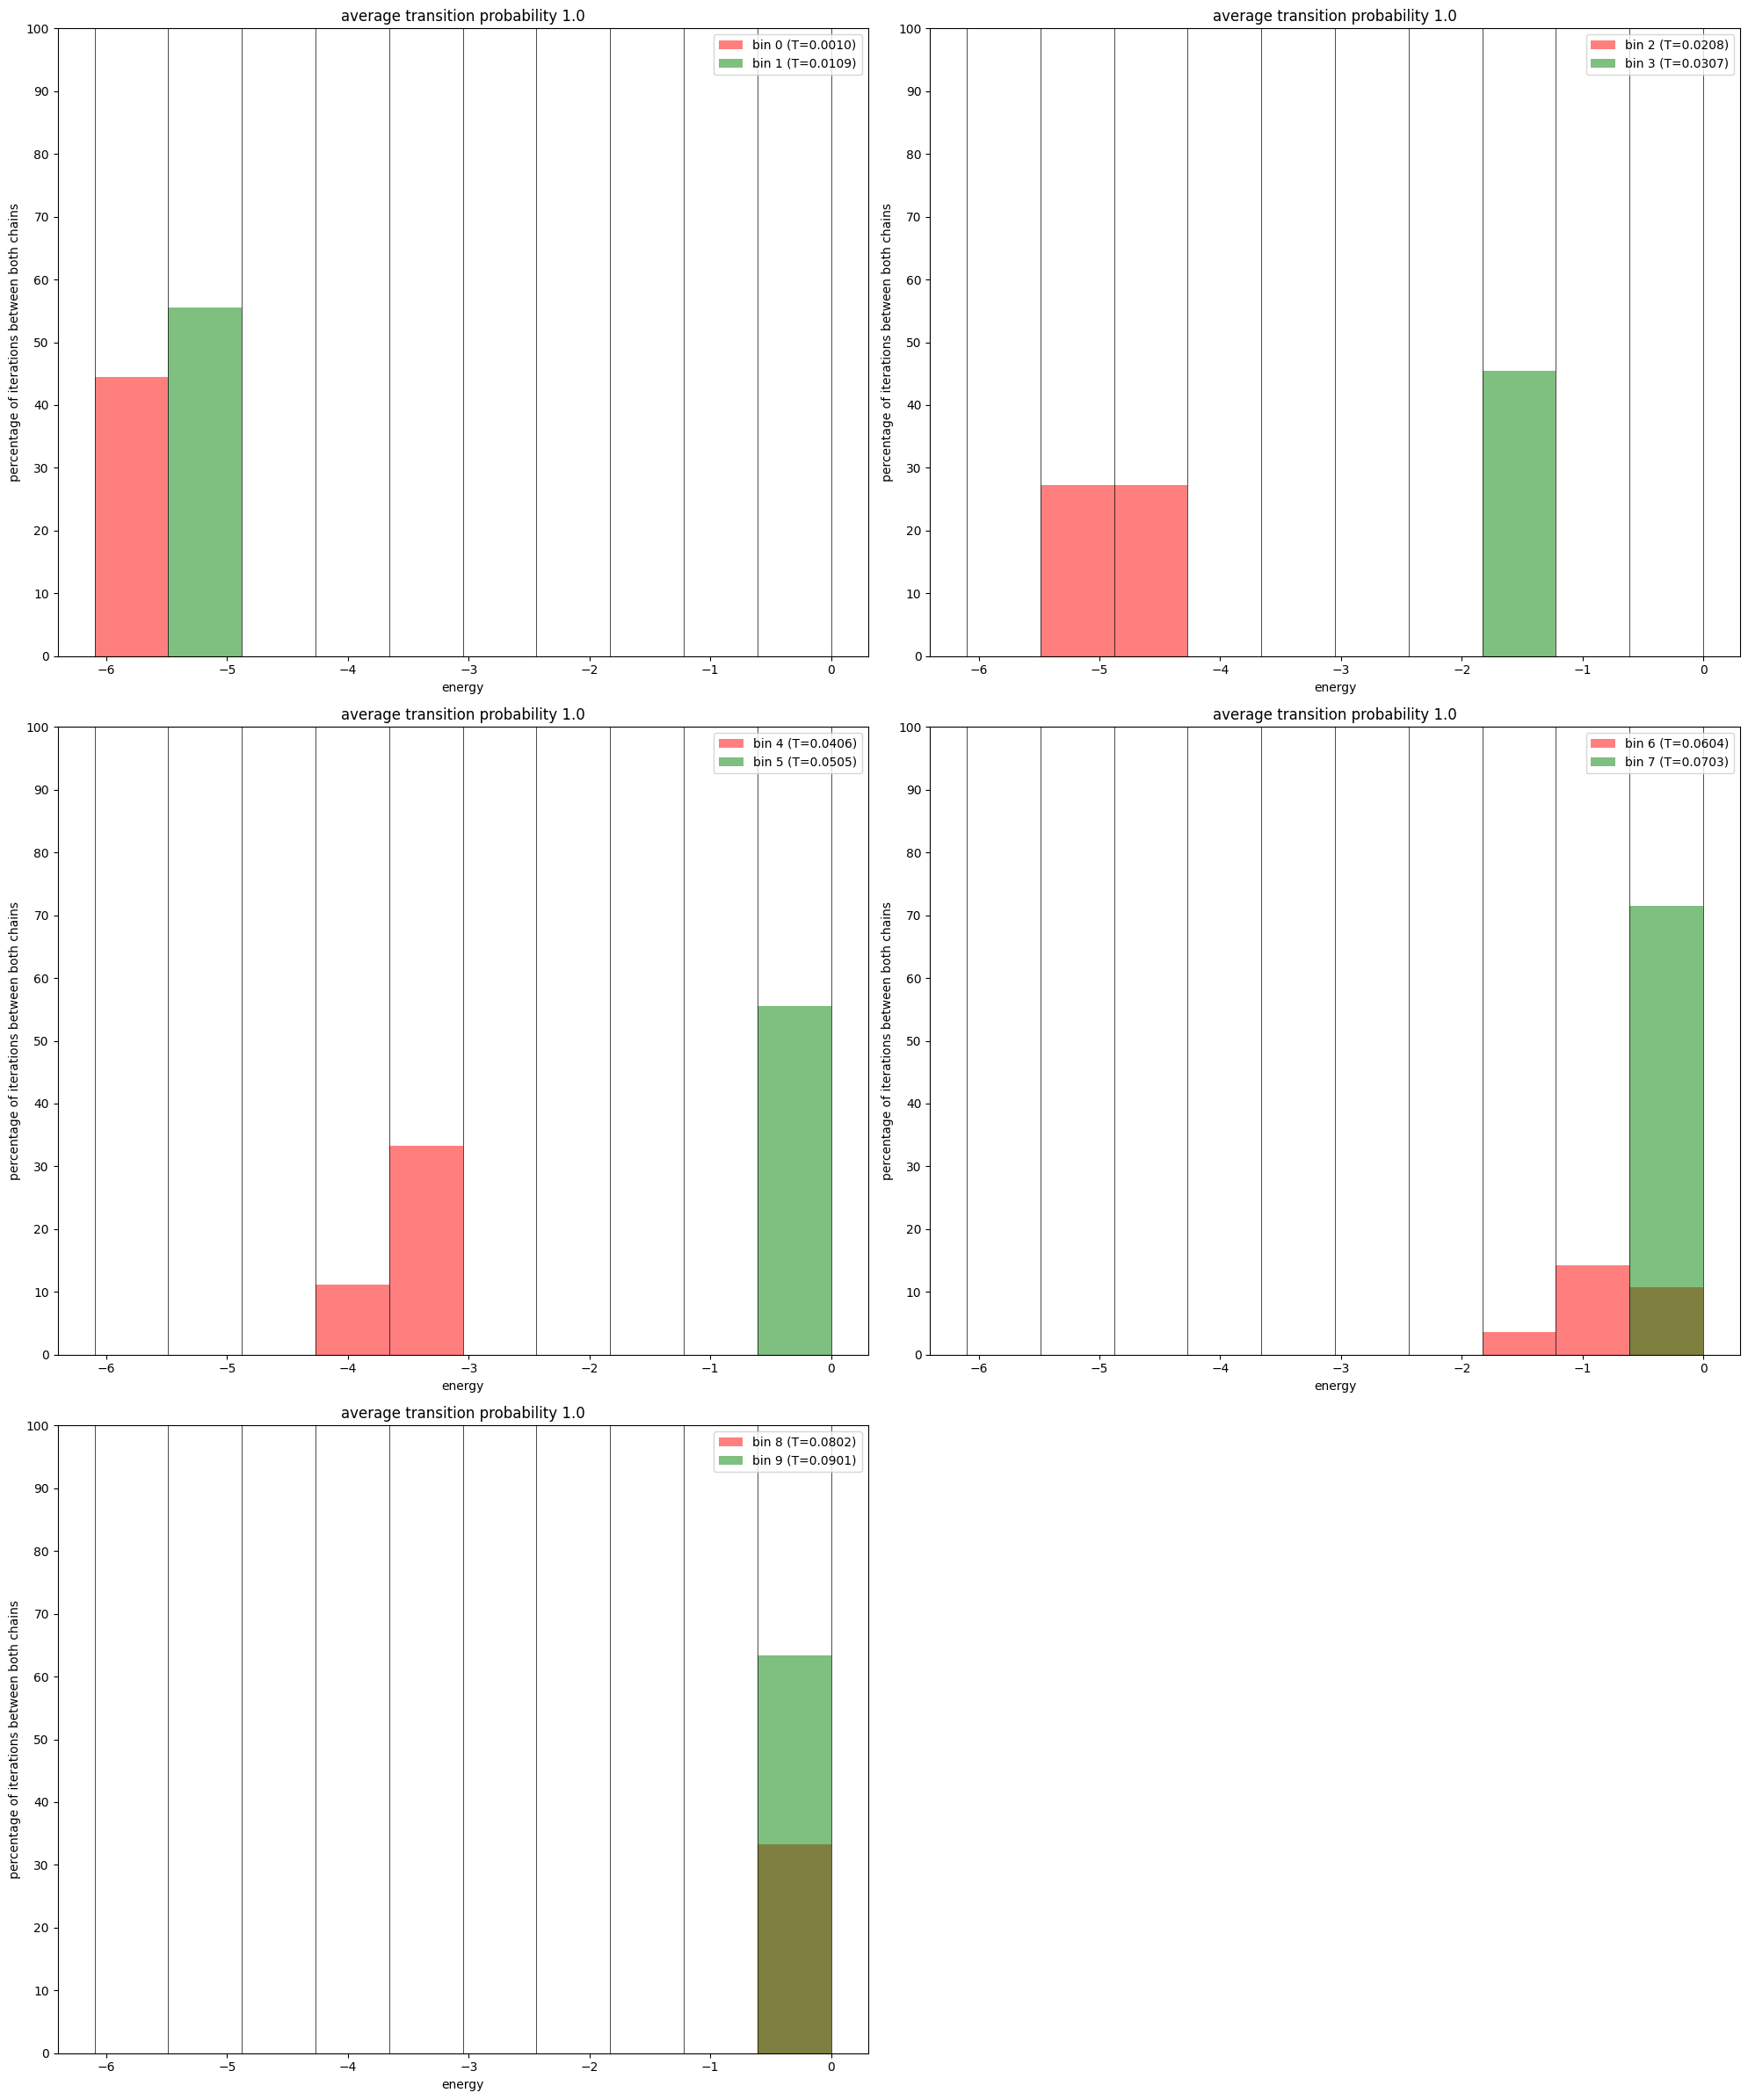

In [35]:
n_even_bins = size // 2 
ncols = 2
#nrows = n_even_bins // ncols 
nrows = -(-n_even_bins // ncols)

subplot_w, subplot_h = 10, 8   # tune once, then it scales itself
fig, axes = plt.subplots(nrows, ncols, figsize=(subplot_w * ncols, subplot_h * nrows))
axes = np.atleast_2d(axes)   # keeps axes[row][col] valid even when nrows or ncols == 1


plot_idx = 0
for b in range(size):
    if b%2==0:
        row = plot_idx // 2
        col = plot_idx % 2
        ax = axes[row][col]

        #data_b = even_rounds_second_half[even_rounds_second_half['bin_index'] == b]['energy']
        #data_b1 = even_rounds_second_half[even_rounds_second_half['bin_index'] == b + 1]['energy']
        data_b = last_X_second_half[last_X_second_half['bin_index'] == b]['energy']
        data_b1 = last_X_second_half[last_X_second_half['bin_index'] == b + 1]['energy']
        total = len(data_b) + len(data_b1)
        weights_b = np.ones(len(data_b)) / total * 100
        weights_b1 = np.ones(len(data_b1)) / total * 100
    
        # bin b
        #axes[row][col].hist(data_b, bins=10, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',weights=weights_b)
        axes[row][col].hist(data_b, bins=bin_edges, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',
                            weights=weights_b)
    
        
        # bin b+1
        axes[row][col].hist(data_b1, bins=bin_edges, density=False, alpha=0.5, color="g", label=f'bin {b+1} (T={temps[b+1]:.4f})',
                           weights=weights_b1)

        for edge in bin_edges:
            axes[row][col].axvline(x=edge, color='black', linewidth=0.5)


        axes[row][col].set_ylim(0, 100)
        axes[row][col].set_yticks(range(0, 101, 10))
        axes[row][col].set_xlabel('energy')
        axes[row][col].set_ylabel('percentage of iterations between both chains')
        axes[row][col].set_title(f'average transition probability {avg_transition_prob(df_exp_stats, b, from_round=number_of_rounds // 2)}')
        axes[row][col].legend()
        plot_idx+=1

for idx in range(plot_idx, nrows * ncols):
    fig.delaxes(axes[idx // ncols][idx % ncols])
plt.tight_layout()
#fig.savefig(f'energy_overlap_bin{b}_{b+1}_even_rounds_second_half.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
bin_edges

array([-6.0981 , -5.48829, -4.87848, -4.26867, -3.65886, -3.04905,
       -2.43924, -1.82943, -1.21962, -0.60981,  0.     ])

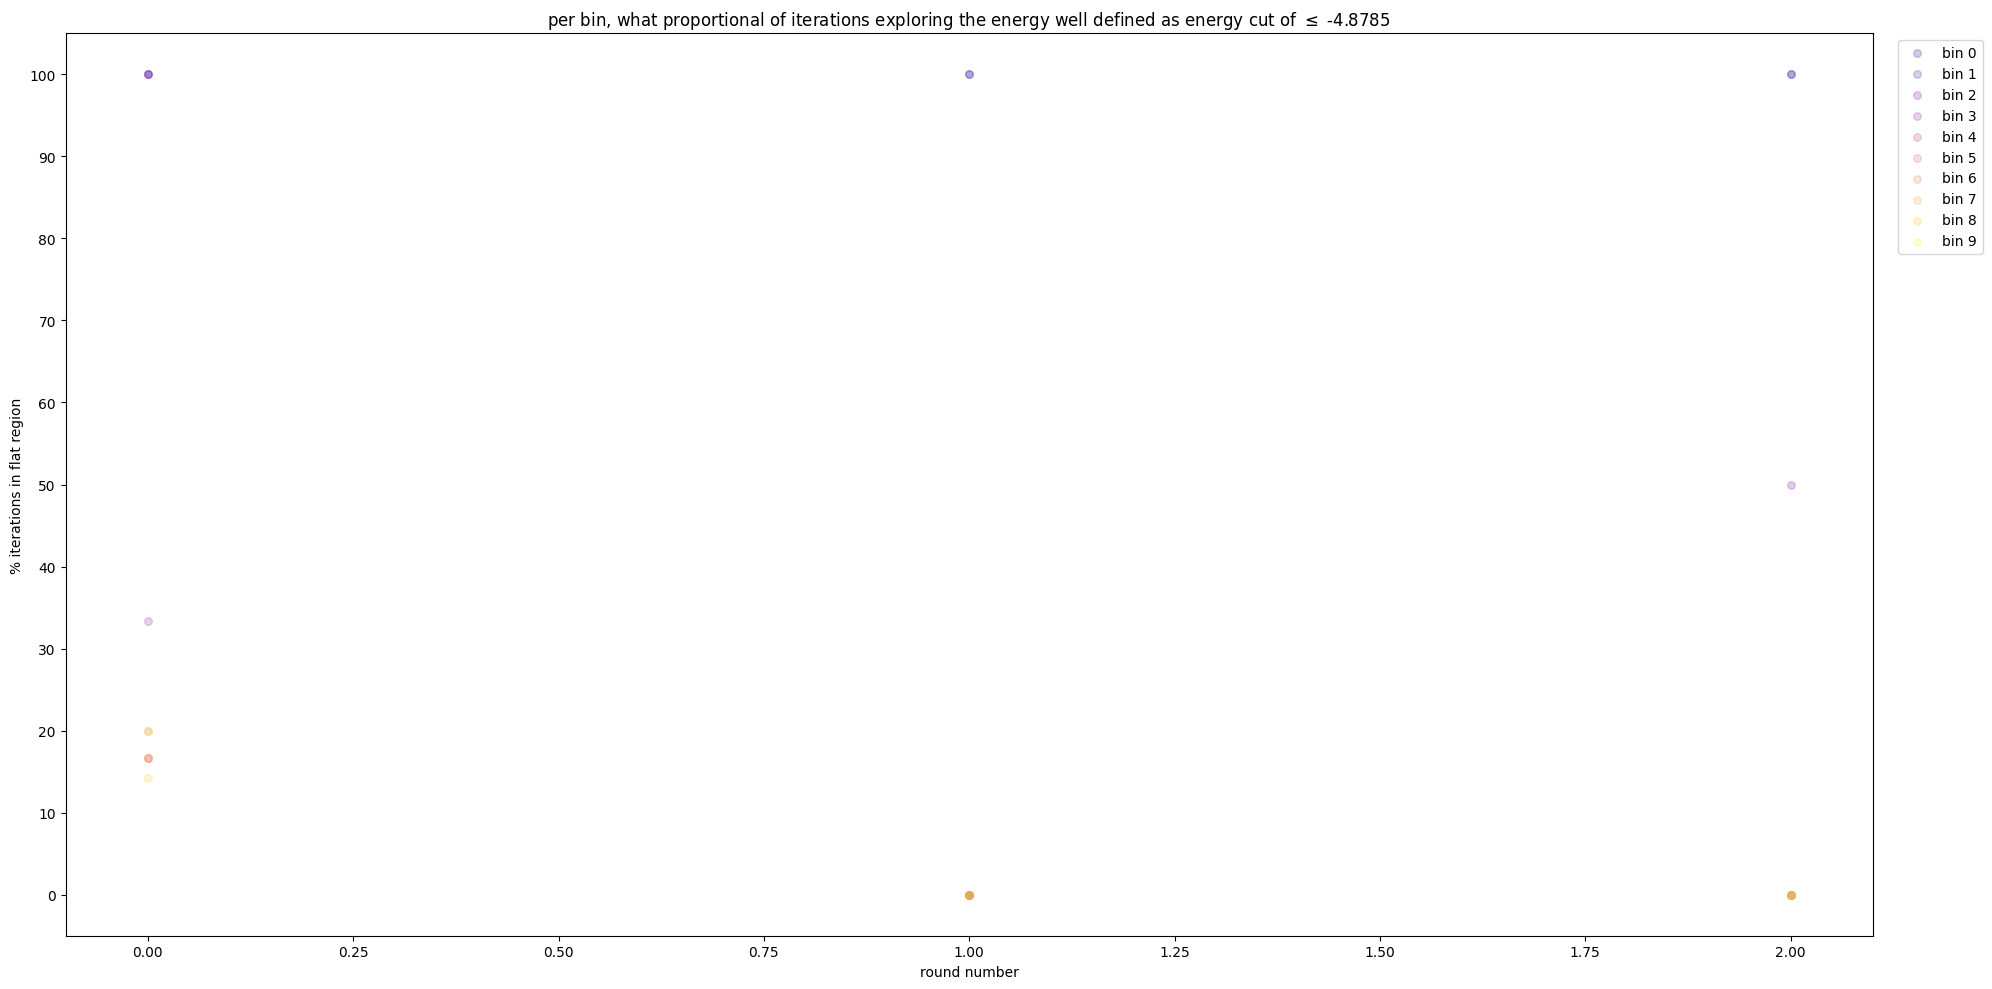

In [37]:
flat_region_threshold = bin_edges[2]  # -1.0517

flat_fraction = (df_exp_stats_intra_rounds
    .groupby(['round_nbr', 'bin_index'])
    .apply(lambda g: (g['energy'] <= flat_region_threshold).sum() / len(g), include_groups=False)
    .reset_index(name='flat_fraction')
)

fig, ax = plt.subplots(figsize=(20, 10))
cmap = plt.get_cmap('plasma', size)
for b in range(size):
    data = flat_fraction[flat_fraction['bin_index'] == b]
    ax.scatter(data['round_nbr'], data['flat_fraction'] * 100, s=30, alpha = 0.2, color=cmap(b), label=f'bin {b}')

ax.set_xlabel('round number')
ax.set_ylabel('% iterations in flat region')
ax.set_yticks(range(0, 101, 10))
ax.set_title(r'per bin, what proportional of iterations exploring the energy well defined as energy cut of $\leq$ '+f'{flat_region_threshold:.4f}')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
#fig.savefig(f'proportion_of_iterations_spent_in_coldest_bin.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
parse_space_string(df_exp_stats['prob'].iloc[1], dtype=float)

array([ 1., -1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.])

In [39]:
df_exp_stats[:3:]

,id,experimentID,round_nbr,temperatures,prob,acceptOrNot,binIndices,energy
0,1,55,0,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0,1 1 1 1 1 1 1 1 1 1,1 0 3 2 5 4 7 6 9 8,-6.0981 -5.4674 -4.7513 -4.3804 -4.1295 -1.366...
1,2,55,1,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 -1.0 1.0 1.0 1.0 1.0 1.0 1.0 -1.0 1.0,1 -1 1 1 1 1 1 1 -1 1,2 0 4 1 6 3 8 5 9 7,-5.4503 -5.9018 -4.2031 -4.6052 -1.7276 -1.294...
2,3,55,2,0.001 0.0109 0.0208 0.0307 0.0406 0.0505 0.060...,1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0,1 1 1 1 1 1 1 1 1 1,3 1 5 0 7 2 9 4 8 6,-4.6897 -5.9363 -3.9528 -5.047 -0.1944 -1.7983...


In [40]:
def prob_Ti_Ti_plus_1(prob_ordered_by_rank, bin_indices):
    sorted_by_bin_indices = np.zeros(len(prob_ordered_by_rank))
    for i in range(len(sorted_by_bin_indices)):
        sorted_by_bin_indices[i] = prob_ordered_by_rank[np.where(bin_indices == i)]
    return sorted_by_bin_indices

In [41]:
#check
prob_ordered_by_rank = parse_space_string(df_exp_stats['prob'].iloc[1], dtype=float)
bin_indices_ = parse_space_string(df_exp_stats['binIndices'].iloc[1])
print(prob_ordered_by_rank, bin_indices_)
prob_Ti_Ti_plus_1(prob_ordered_by_rank,bin_indices_)

[ 1. -1.  1.  1.  1.  1.  1.  1. -1.  1.] [2 0 4 1 6 3 8 5 9 7]


array([-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.])

In [42]:
# parse prob into a 2D array, shape (n_rounds, n_ranks)
#You're right to question it — .values converts the pandas Series to a numpy array before passing to np.vstack. But since np.vstack can handle a Series directly you don't need it.
probs_by_rank = np.vstack(df_exp_stats['prob'].apply(parse_space_string, dtype=float).values)
traj = np.vstack(df_exp_stats['binIndices'].apply(parse_space_string).values)  # shape (n_rounds, n_ranks)

probs_by_bin = np.vstack([
    prob_Ti_Ti_plus_1(probs_by_rank[r], traj[r]) 
    for r in range(number_of_rounds)
])


In [43]:
even_round_true_or_false = df_exp_stats['round_nbr'] % 2 == 0

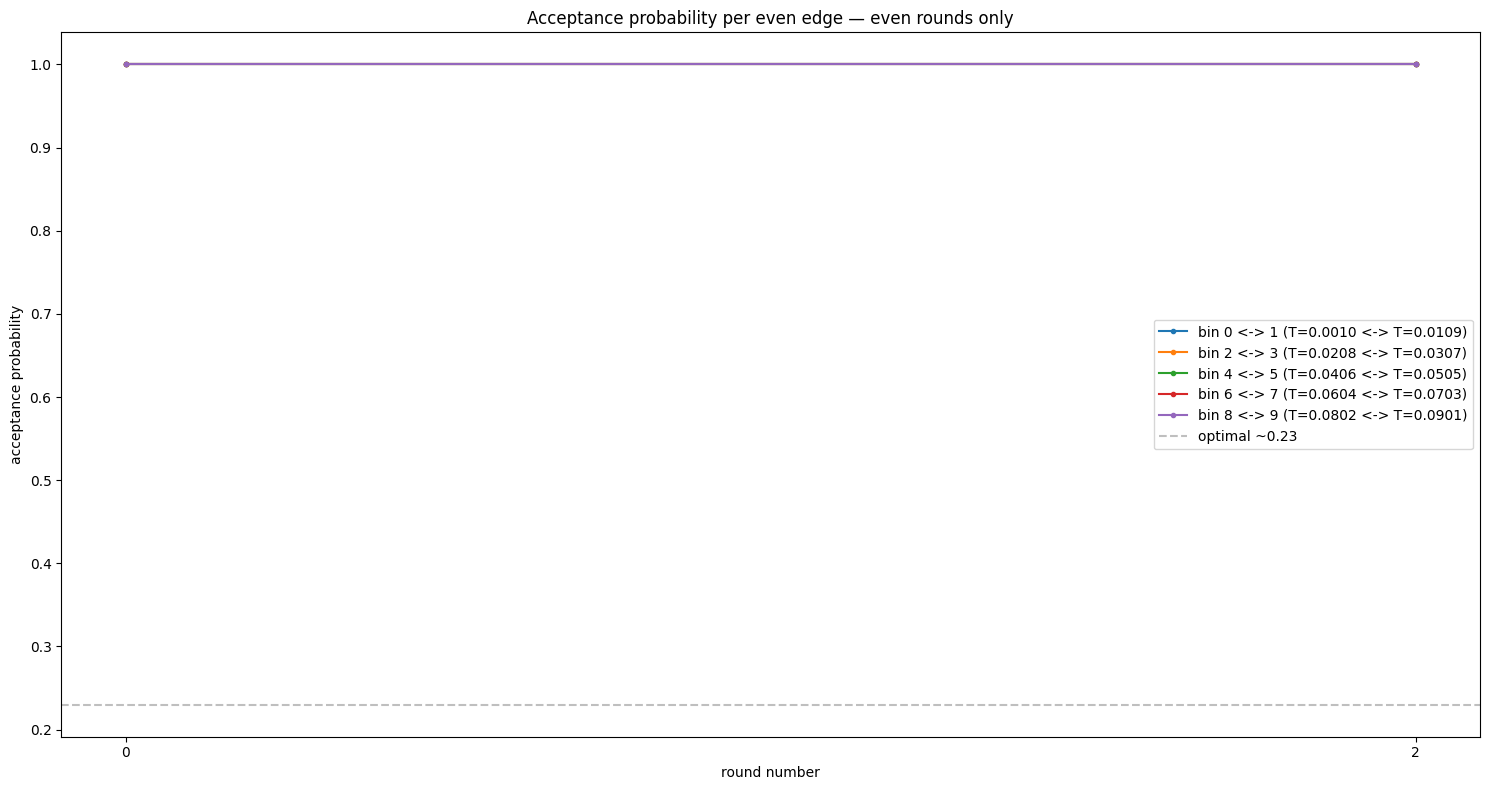

In [44]:
fig, ax = plt.subplots(figsize=(15, 8))

for b in range(0, size - 1, 2):
    ax.plot(
        df_exp_stats.loc[even_round_true_or_false, 'round_nbr'],
        probs_by_bin[even_round_true_or_false, b],
        label=f'bin {b} <-> {b+1} (T={temps[b]:.4f} <-> T={temps[b+1]:.4f})',
        marker='o', markersize=3
    )

ax.set_xlabel('round number')
ax.set_xticks(df_exp_stats.loc[even_round_true_or_false, 'round_nbr'])
ax.set_ylabel('acceptance probability')
ax.set_title('Acceptance probability per even edge — even rounds only')
ax.axhline(0.23, color='gray', linestyle='--', alpha=0.5, label='optimal ~0.23')
ax.legend()

plt.tight_layout()
#fig.savefig('acceptance_prob_even_edges_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
odd_rounds = df_curves[df_curves['round_nbr'] % 2 == 1]
odd_rounds_intra = df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['round_nbr'] % 2 == 1]
X = 50
last_X = (odd_rounds_intra
    .groupby(['round_nbr', 'rank'])
    .apply(lambda g: g.nlargest(X, 'it_no_intra_round'), include_groups=False)
    .reset_index(drop=True)
)

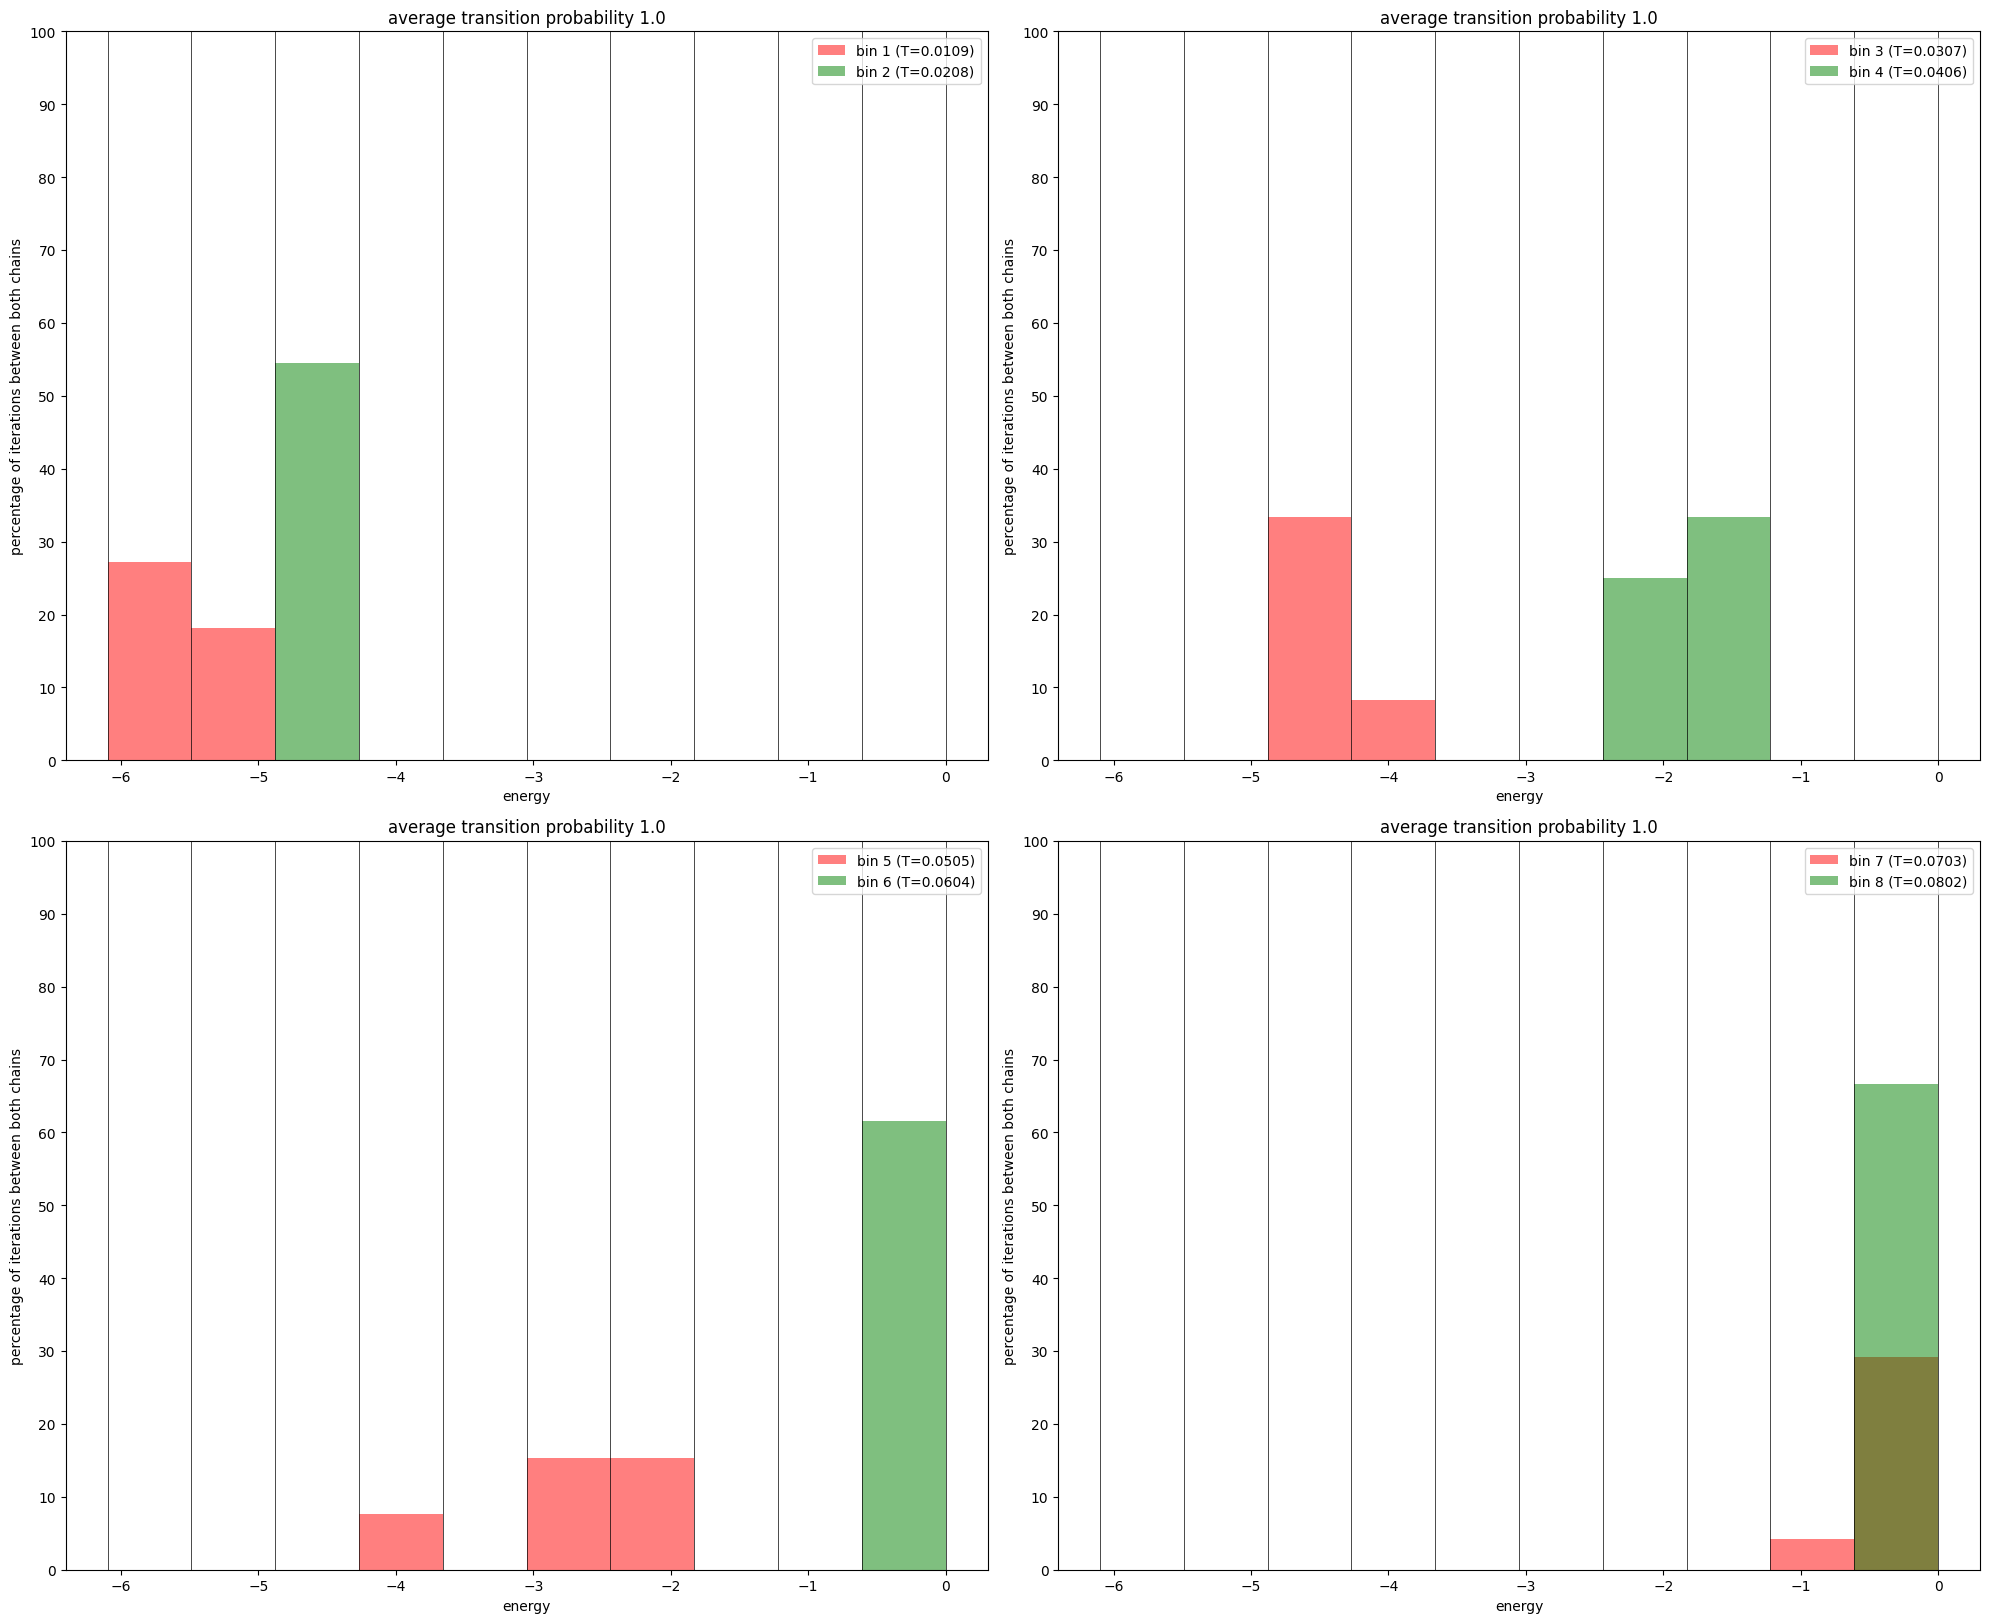

In [53]:
n_odd_bins = size // 2  # pairs
ncols = 2
nrows = -(-n_odd_bins // ncols)
subplot_w, subplot_h = 10, 8   # tune once, then it scales itself
fig, axes = plt.subplots(nrows, ncols, figsize=(subplot_w * ncols, subplot_h * nrows))
axes = np.atleast_2d(axes)   # keeps axes[row][col] valid even when nrows or ncols == 1


plot_idx = 0
for b in range(size):
    if b%2==1:
        row = plot_idx // 2
        col = plot_idx % 2
        ax = axes[row][col]
        if b + 1 > size - 1:
            axes[-1][-1].set_visible(False)
            break
            
        data_b = last_X[last_X['bin_index'] == b]['energy']
        data_b1 = last_X[last_X['bin_index'] == b + 1]['energy']
        #data_b = odd_rounds[even_rounds['bin_index'] == b]['energy']
        #data_b1 = odd_rounds[even_rounds['bin_index'] == b + 1]['energy']
        total = len(data_b) + len(data_b1)
        weights_b = np.ones(len(data_b)) / total * 100
        weights_b1 = np.ones(len(data_b1)) / total * 100
    
        # bin b
        #axes[row][col].hist(data_b, bins=10, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',weights=weights_b)
        axes[row][col].hist(data_b, bins=bin_edges, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',
                            weights=weights_b)
    
        
        # bin b+1
        axes[row][col].hist(data_b1, bins=bin_edges, density=False, alpha=0.5, color="g", label=f'bin {b+1} (T={temps[b+1]:.4f})',
                           weights=weights_b1)

        for edge in bin_edges:
            axes[row][col].axvline(x=edge, color='black', linewidth=0.5)


        axes[row][col].set_ylim(0, 100)
        axes[row][col].set_yticks(range(0, 101, 10))
        axes[row][col].set_xlabel('energy')
        axes[row][col].set_ylabel('percentage of iterations between both chains')
        axes[row][col].set_title(f'average transition probability {avg_transition_prob(df_exp_stats, b, even=False)}')
        axes[row][col].legend()
        plot_idx+=1

for idx in range(plot_idx, nrows * ncols):
    fig.delaxes(axes[idx // ncols][idx % ncols])
plt.tight_layout()
#fig.savefig(f'energy_overlap_bin{b}_{b+1}_even_rounds.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
odd_rounds_second_half = df_curves[(df_curves['round_nbr'] % 2 == 1 ) & (df_curves['round_nbr'] > number_of_rounds // 2 )]
odd_rounds_intra_second_half = df_exp_stats_intra_rounds[(df_exp_stats_intra_rounds['round_nbr'] % 2 == 1) & (df_exp_stats_intra_rounds['round_nbr'] > number_of_rounds // 2)]
X = 50
last_X_second_half = (odd_rounds_intra_second_half
    .groupby(['round_nbr', 'rank'])
    .apply(lambda g: g.nlargest(X, 'it_no_intra_round'), include_groups=False)
    .reset_index(drop=True)
)

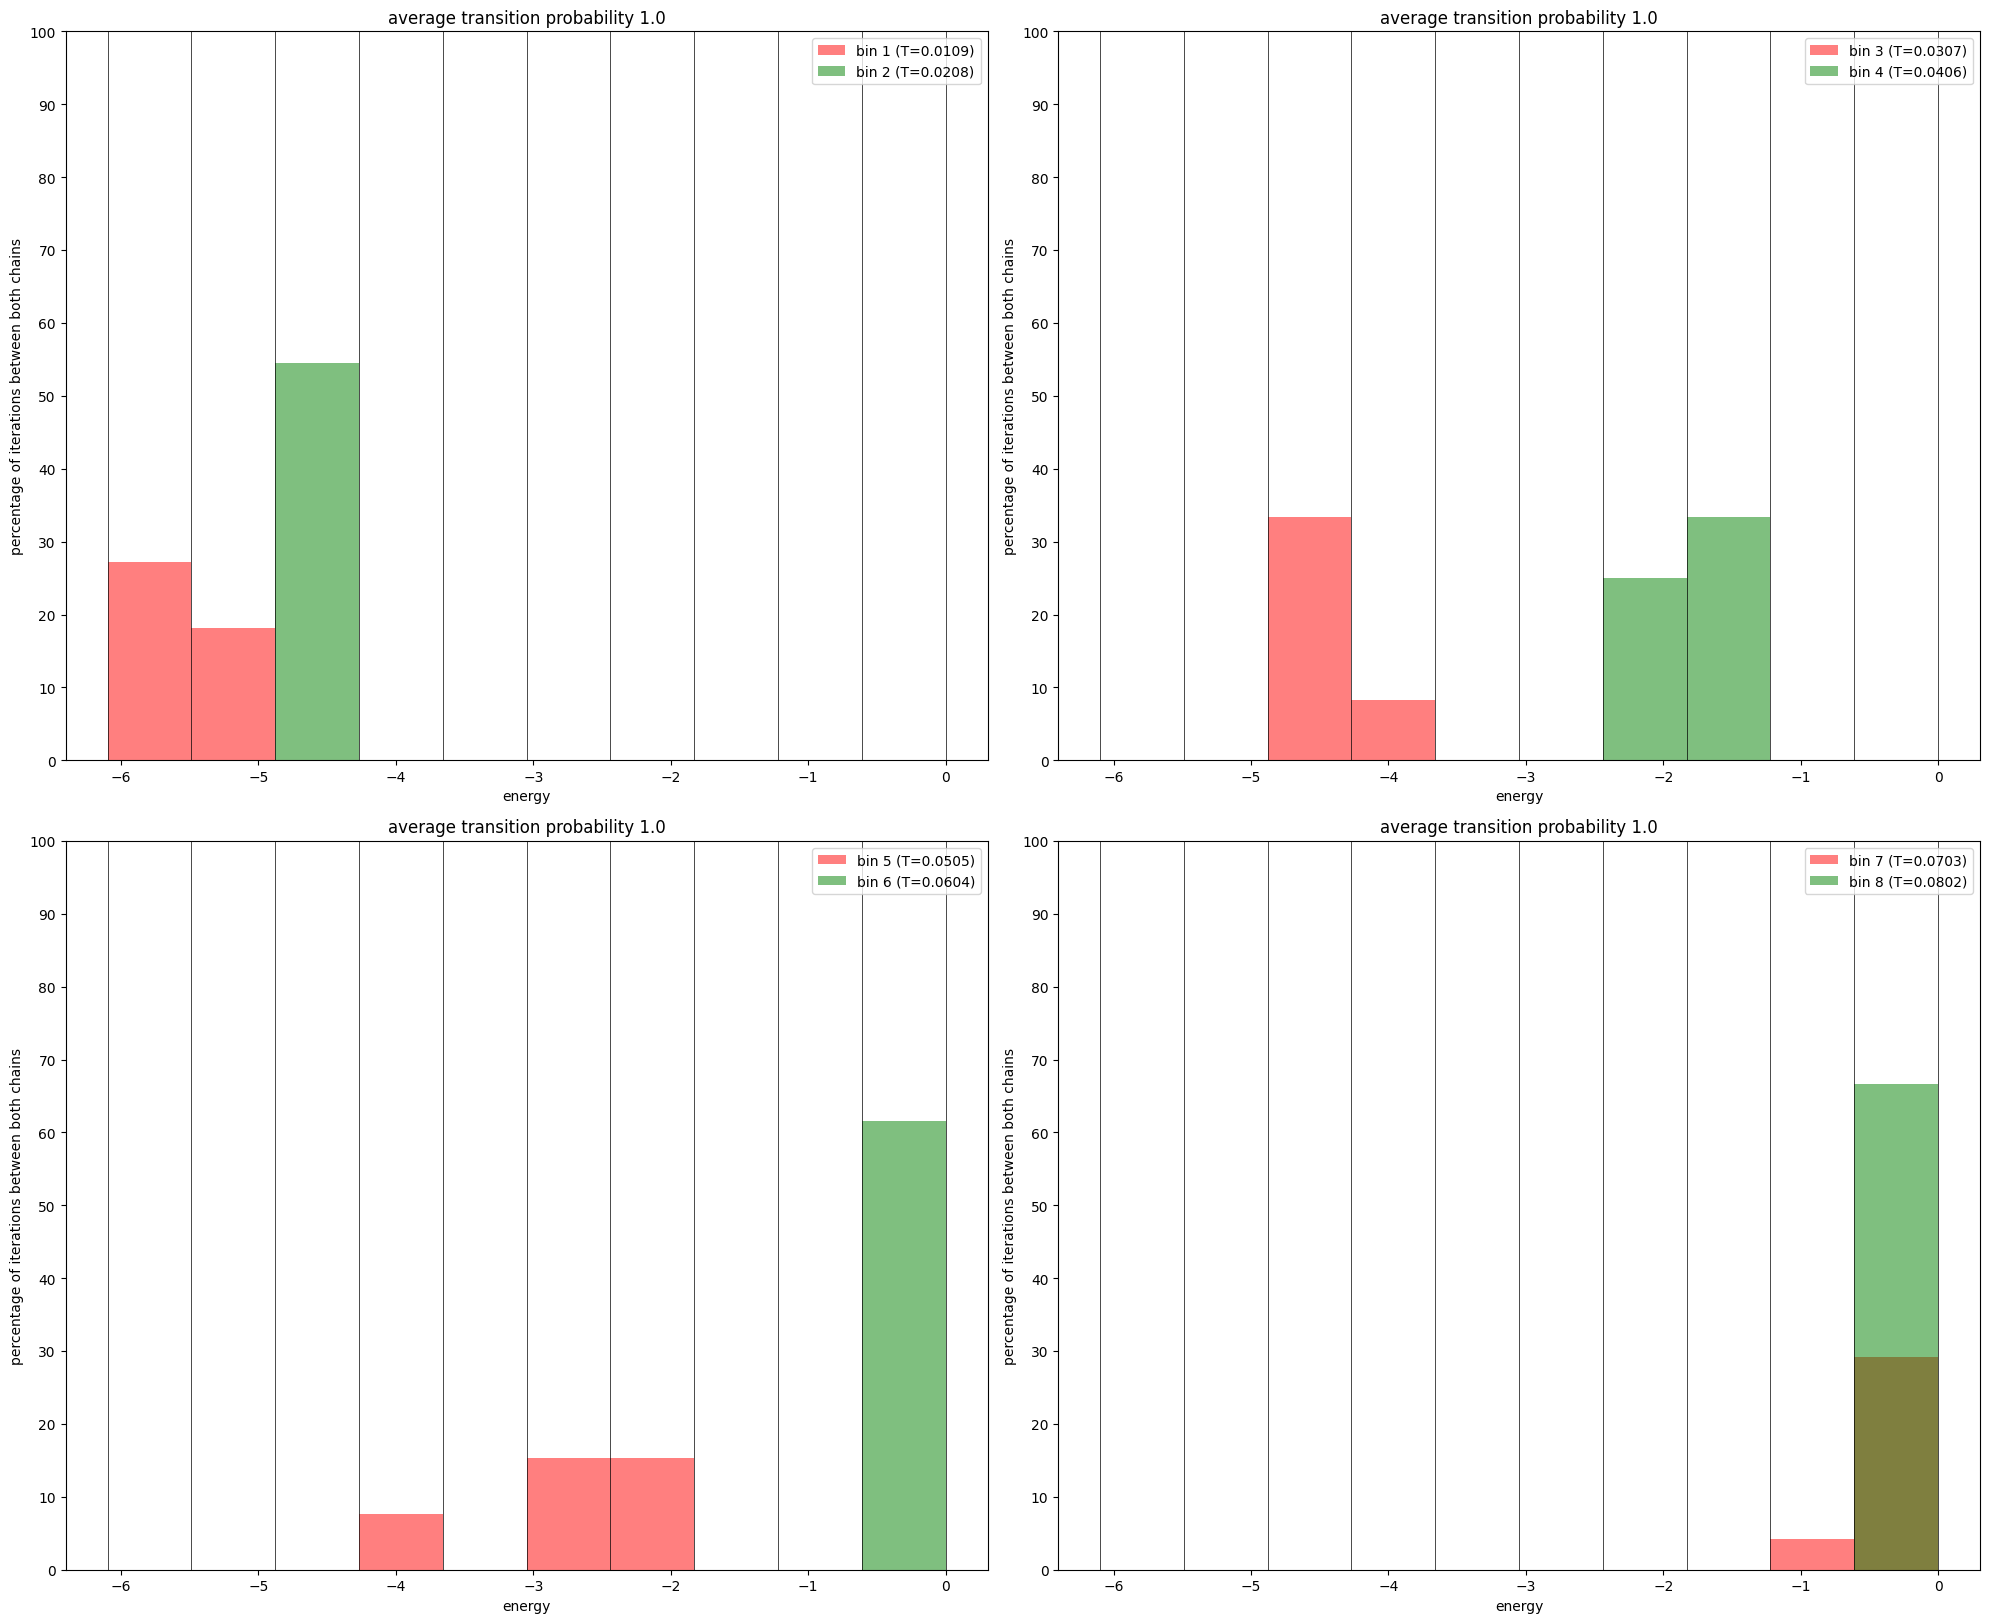

In [55]:
n_odd_bins = size // 2  # pairs
ncols = 2
nrows = -(-n_odd_bins // ncols)
subplot_w, subplot_h = 10, 8   # tune once, then it scales itself
fig, axes = plt.subplots(nrows, ncols, figsize=(subplot_w * ncols, subplot_h * nrows))
axes = np.atleast_2d(axes)   # keeps axes[row][col] valid even when nrows or ncols == 1

plot_idx = 0
for b in range(size):
    if b%2==1:
        row = plot_idx // 2
        col = plot_idx % 2
        ax = axes[row][col]
        if b + 1 > size - 1:
            axes[-1][-1].set_visible(False)
            break
            
        data_b = last_X[last_X['bin_index'] == b]['energy']
        data_b1 = last_X[last_X['bin_index'] == b + 1]['energy']
        #data_b = odd_rounds[even_rounds['bin_index'] == b]['energy']
        #data_b1 = odd_rounds[even_rounds['bin_index'] == b + 1]['energy']
        total = len(data_b) + len(data_b1)
        weights_b = np.ones(len(data_b)) / total * 100
        weights_b1 = np.ones(len(data_b1)) / total * 100
    
        # bin b
        #axes[row][col].hist(data_b, bins=10, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',weights=weights_b)
        axes[row][col].hist(data_b, bins=bin_edges, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',
                            weights=weights_b)
    
        
        # bin b+1
        axes[row][col].hist(data_b1, bins=bin_edges, density=False, alpha=0.5, color="g", label=f'bin {b+1} (T={temps[b+1]:.4f})',
                           weights=weights_b1)

        for edge in bin_edges:
            axes[row][col].axvline(x=edge, color='black', linewidth=0.5)


        axes[row][col].set_ylim(0, 100)
        axes[row][col].set_yticks(range(0, 101, 10))
        axes[row][col].set_xlabel('energy')
        axes[row][col].set_ylabel('percentage of iterations between both chains')
        axes[row][col].set_title(f'average transition probability {avg_transition_prob(df_exp_stats, b, even=False, from_round=number_of_rounds // 2)}')
        axes[row][col].legend()
        plot_idx+=1

for idx in range(plot_idx, nrows * ncols):
    fig.delaxes(axes[idx // ncols][idx % ncols])
plt.tight_layout()
#fig.savefig(f'energy_overlap_bin{b}_{b+1}_even_rounds.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
odd_round_true_or_false = df_exp_stats['round_nbr'] % 2 == 1

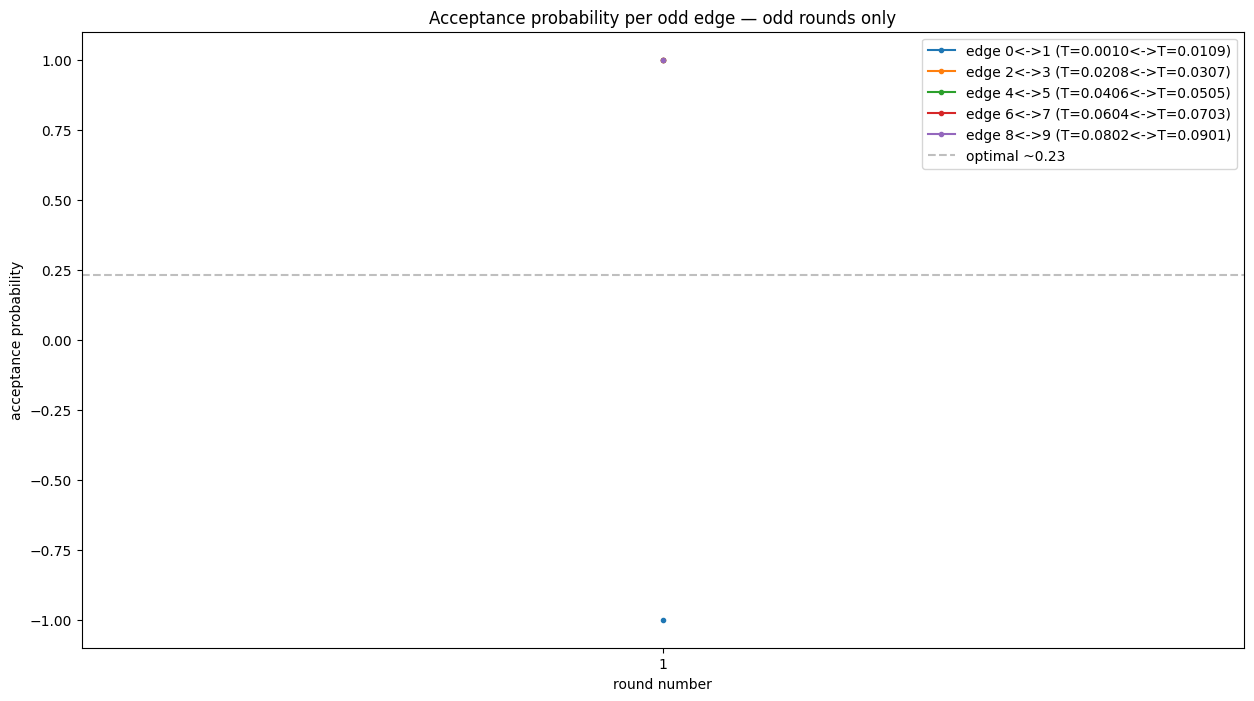

In [57]:
fig, ax = plt.subplots(figsize=(15, 8))

for b in range(0, size - 1, 2):
    ax.plot(
        df_exp_stats.loc[odd_round_true_or_false, 'round_nbr'],
        probs_by_bin[odd_round_true_or_false, b],
        label=f'edge {b}<->{b+1} (T={temps[b]:.4f}<->T={temps[b+1]:.4f})',
        marker='o', markersize=3
    )

ax.set_xlabel('round number')
ax.set_xticks(df_exp_stats.loc[odd_round_true_or_false, 'round_nbr'])
ax.set_ylabel('acceptance probability')
ax.set_title('Acceptance probability per odd edge — odd rounds only')
ax.axhline(0.23, color='gray', linestyle='--', alpha=0.5, label='optimal ~0.23')
ax.legend()

#plt.tight_layout()
#fig.savefig('acceptance_prob_odd_edges.png', dpi=150, bbox_inches='tight')
plt.show()

The following plots the energy and probablity distributions between rounds, ideally the top temperature accepts $\approx 80\%$ of energy increasing deformations and the lowest temperature about $\approx 20\%$.

(This is just a heuristic guess Rhoslyn you need to check the literature for some ball park estimates.)

In [58]:
df_exp_stats_intra_rounds[:5:]

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round
0,1,1,0,0,0.001,1.000,0.00000,1,-5.987075,0,0.006720,0,0
1,2,2,0,1738,0.001,3.606,-0.04585,0,-6.067815,0,273.699250,0,1738
2,3,3,0,3504,0.001,1.231,-0.00742,0,-6.095628,0,551.601833,0,3504
3,4,4,0,5285,0.001,0.000,0.37709,0,-6.086472,0,835.861915,0,5285
4,5,5,0,7032,0.001,0.000,3.99255,0,-6.114928,0,1122.369781,0,7032


In [59]:
energy_increasing = df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['deltaE'] > 0]

In [60]:
def suggest_drag_factor(df, bin_index=0):
    counts = (df[df['bin_index'] == bin_index]
              .groupby('round_nbr')
              .size())
    return int(counts.min() / 2)

dragfactor = suggest_drag_factor(df_exp_stats_intra_rounds)
print(f"Suggested drag factor: {dragfactor}")


Suggested drag factor: 2


In [73]:
dragfactor = 5

energy_increasing = energy_increasing.sort_values(['rank', 'it_no']) #sorts by rank and then it_no

# groupby('rank') splits the dataframe into groups, one per rank
# .apply(func) then applies func to each group independently
# rolling(window=3000) is a built-in pandas method
# for each row it looks back at the previous 3000 rows and computes the mean
# min_periods=1 means if there are fewer than 3000 rows available
# (e.g. at the start) it averages over however many are available


energy_increasing['exp(P)'] = energy_increasing.groupby('rank')['prob'].transform(lambda x: x.rolling(window=dragfactor, min_periods=1).mean())
energy_increasing['exp(delE)'] = energy_increasing.groupby('rank')['deltaE'].transform(lambda x: x.rolling(window=dragfactor, min_periods=1).mean())



In [74]:
energy_increasing[::40].head()

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round,exp(P),exp(delE)
3,4,4,0,5285,0.0010,0.000,0.37709,0,-6.086472,0,835.861915,0,5285,0.000,0.37709
57,58,58,4,4977,0.0406,0.621,0.69123,0,-4.465383,4,717.081992,0,4977,0.761,0.42089
164,165,165,8,46940,0.0901,1.000,0.00058,1,-0.000129,9,3577.969895,2,19060,1.000,0.00059


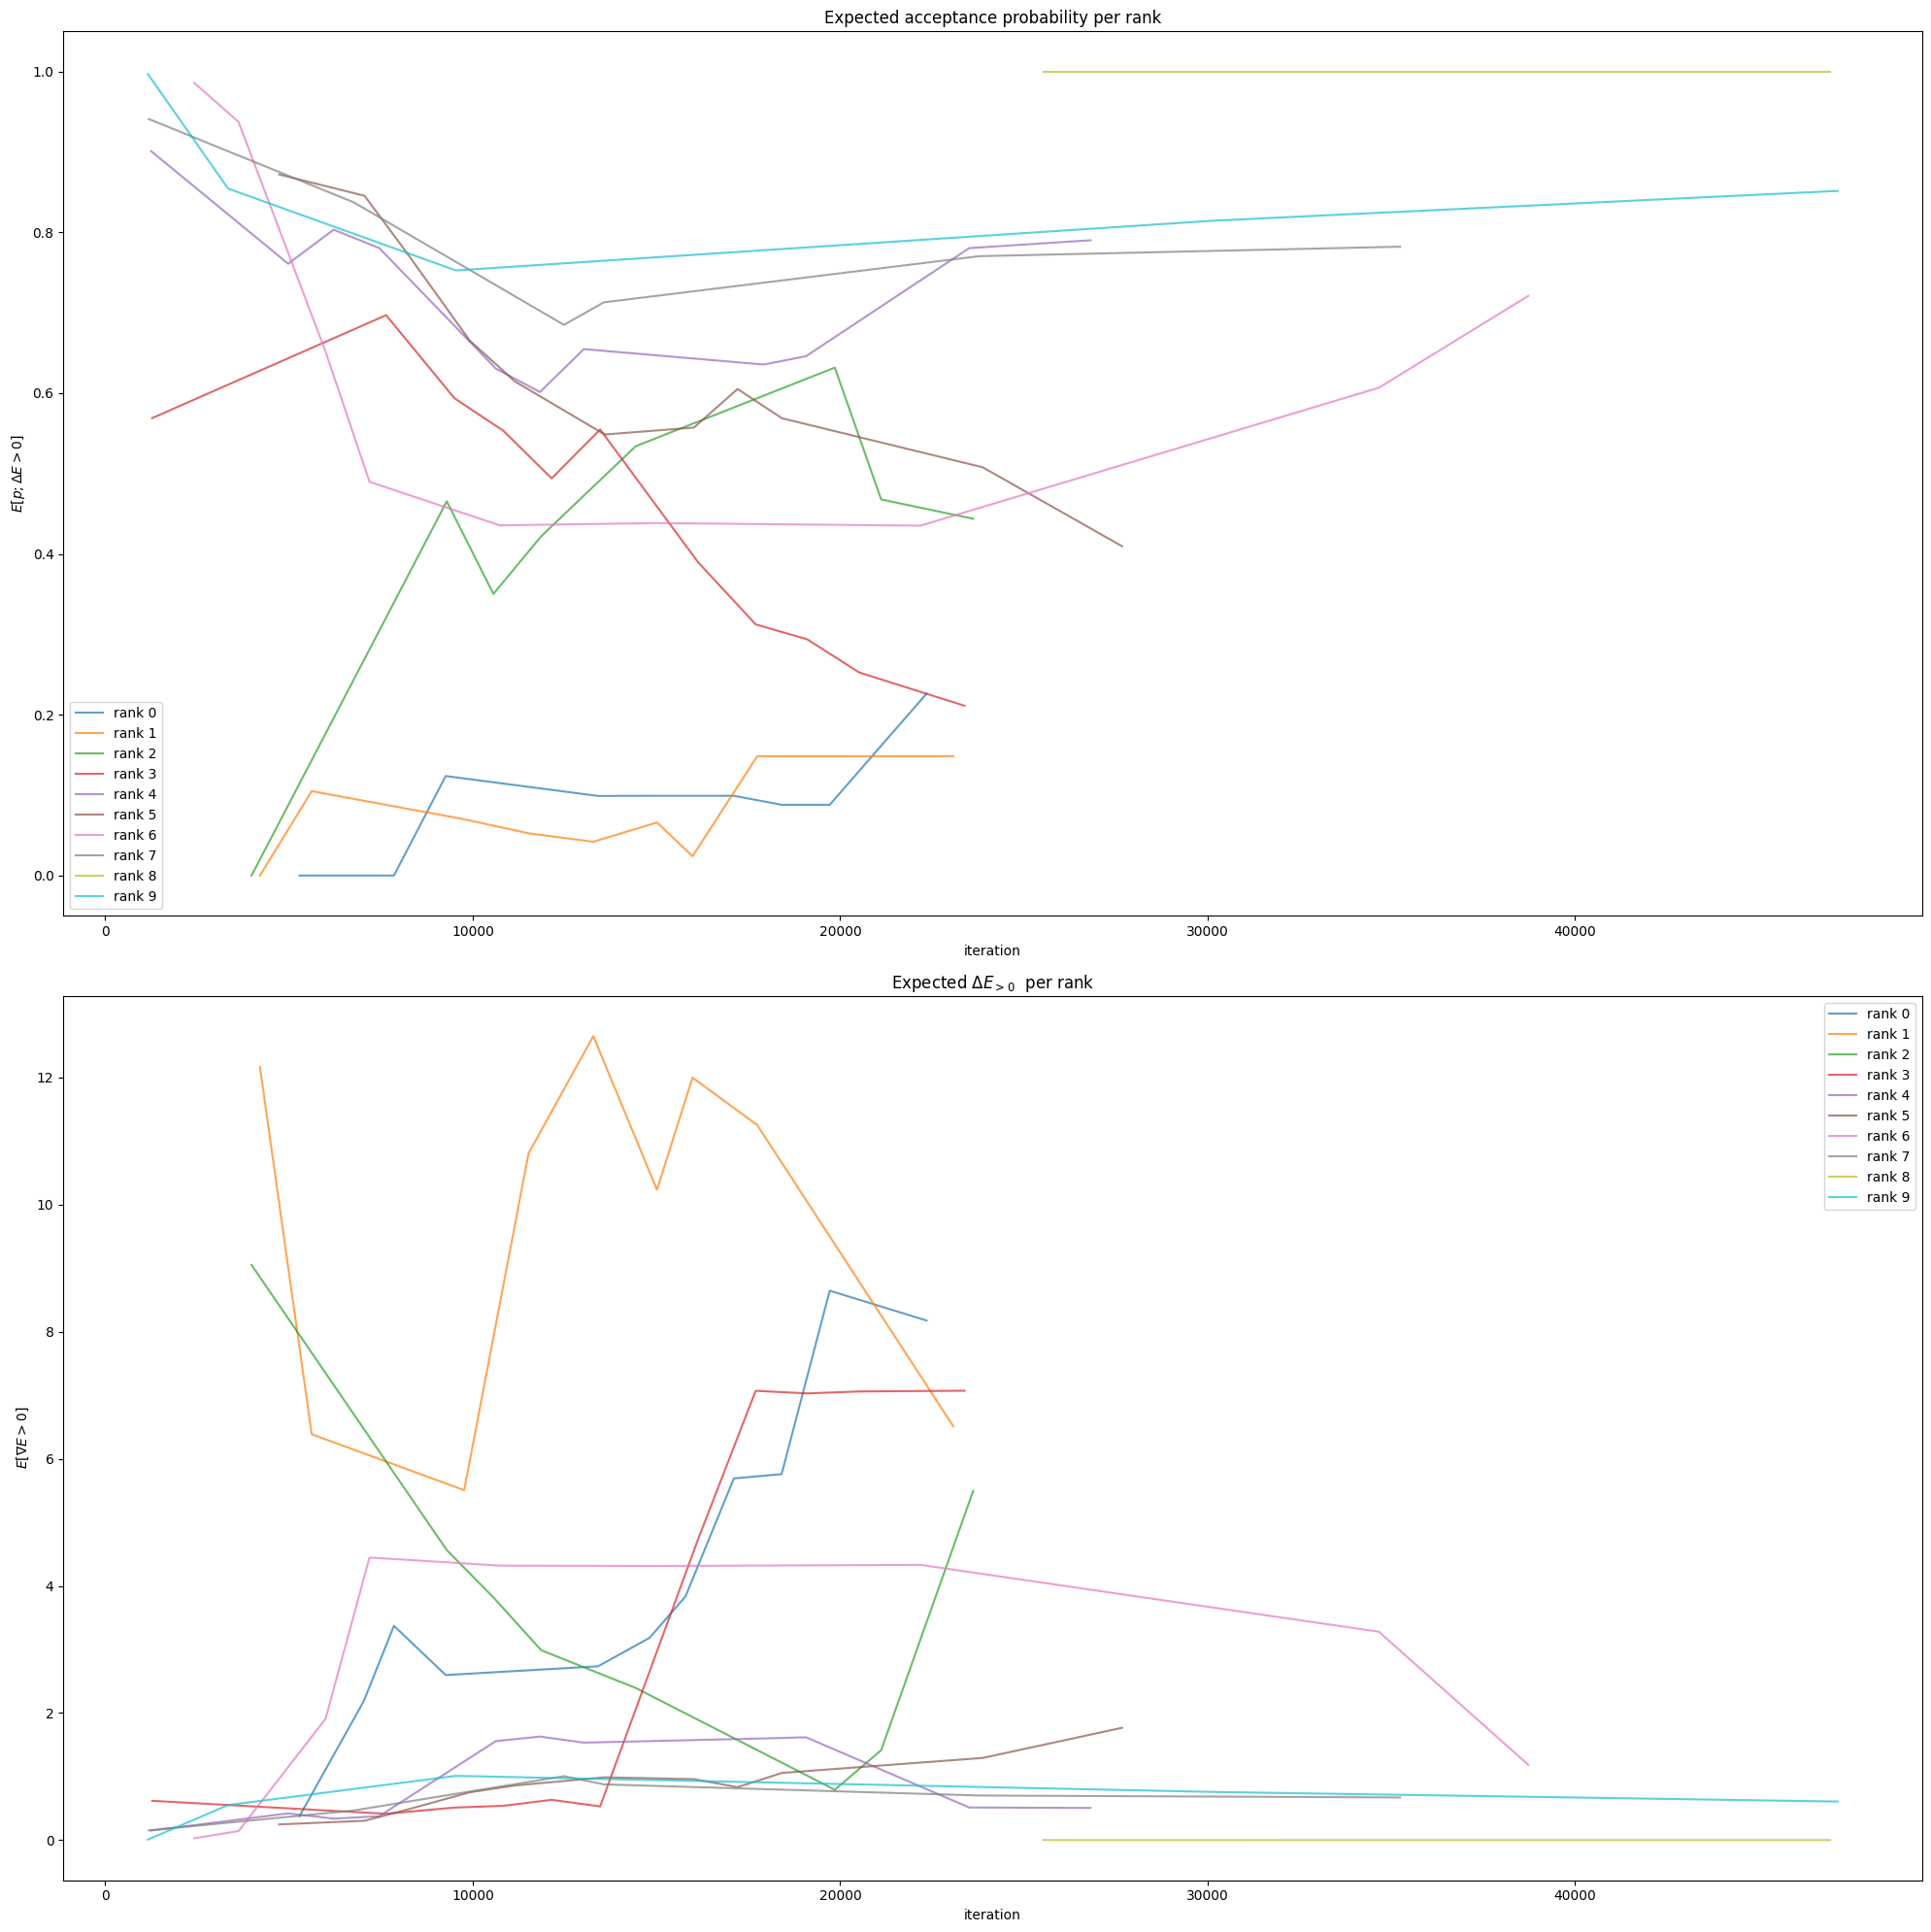

In [75]:
fig, axes = plt.subplots(2, 1, figsize=(20, 20))

cmap = plt.get_cmap('tab10', size)

for r in range(size):
    rank_data = energy_increasing[energy_increasing['rank'] == r]
    
    axes[0].plot(rank_data['it_no'], rank_data['exp(P)'],
                 color=cmap(r), label=f'rank {r}', alpha=0.7)
    
    axes[1].plot(rank_data['it_no'], rank_data['exp(delE)'],
                 color=cmap(r), label=f'rank {r}', alpha=0.7)

axes[0].set_xlabel('iteration')
axes[0].set_ylabel(r'$E[p; \Delta E>0]$')
axes[0].set_title('Expected acceptance probability per rank')
axes[0].legend()

axes[1].set_xlabel('iteration')
axes[1].set_ylabel(r'$E[\nabla E >0]$')
axes[1].set_title(r'Expected $\Delta E_{>0}$  per rank')
axes[1].legend()

plt.tight_layout()
#fig.savefig('intra_round_rolling_averages_per_rank.png', dpi=150, bbox_inches='tight')
plt.show()

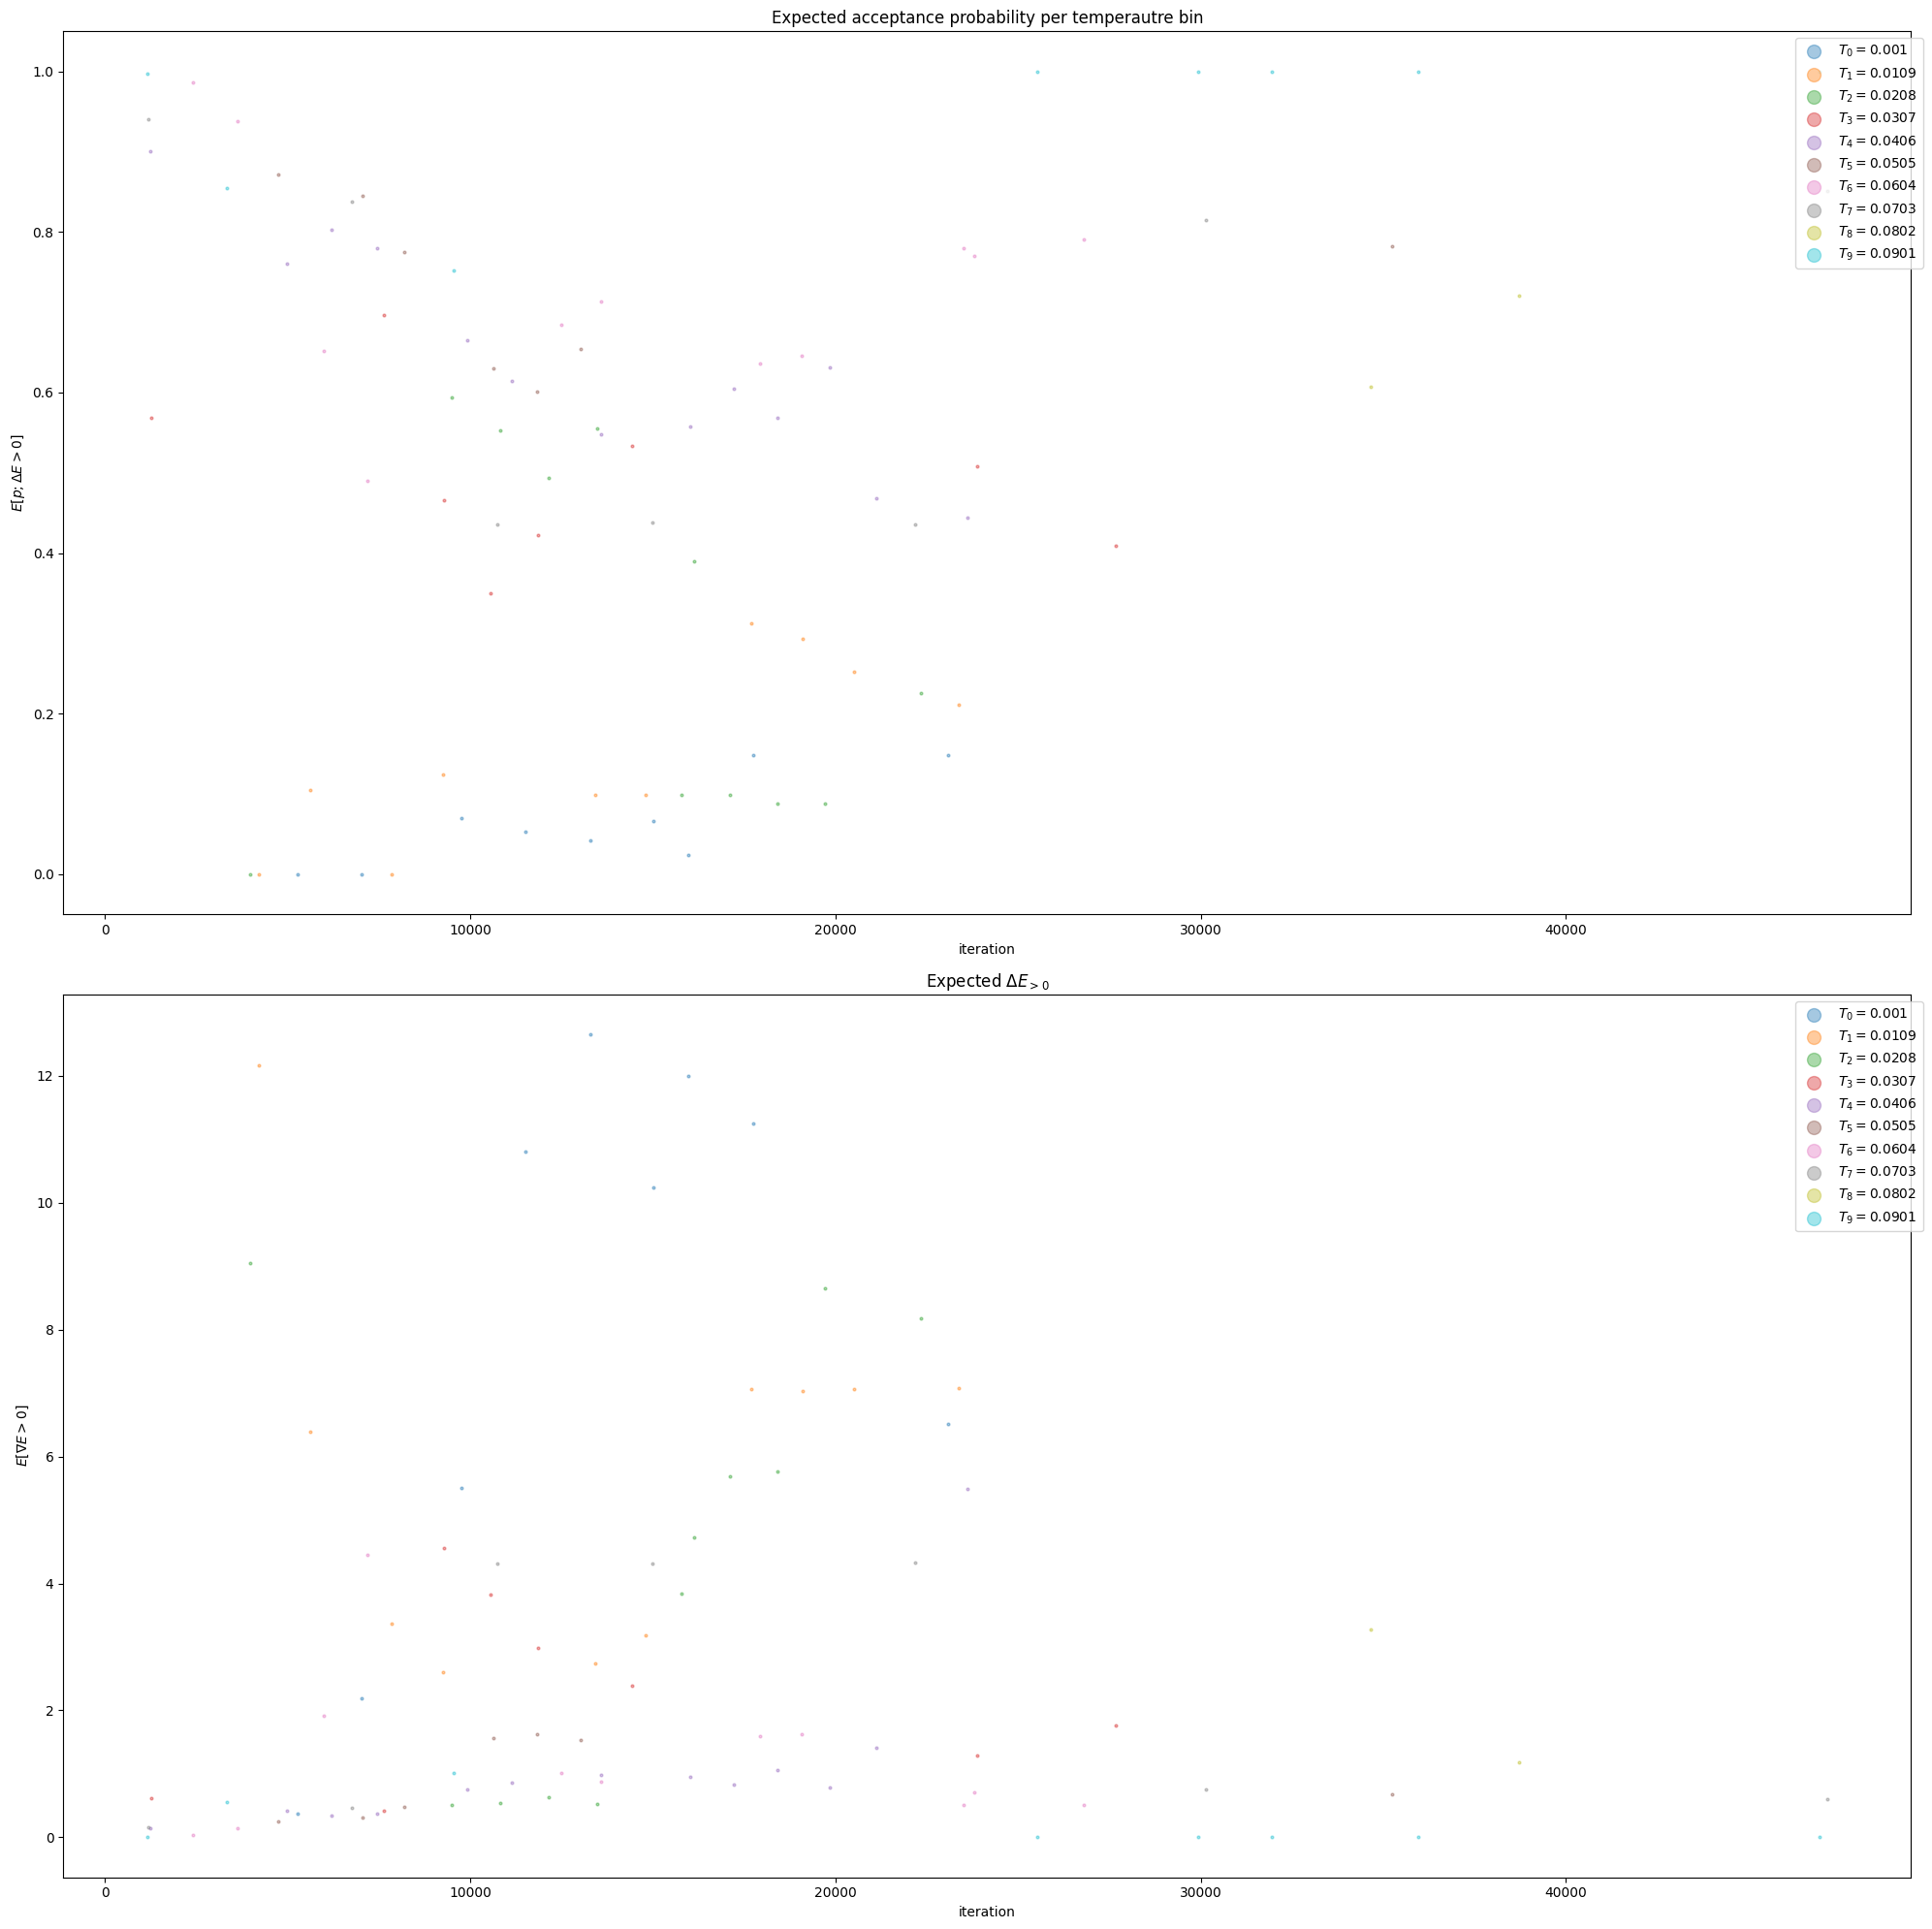

In [79]:
fig, axes = plt.subplots(2, 1, figsize=(20, 20))

cmap = plt.get_cmap('tab10', size)

for b in range(size):
    bin_data = energy_increasing[energy_increasing['bin_index'] == b]
    
    axes[0].scatter(bin_data['it_no'], bin_data['exp(P)'], s=4,
                 color=cmap(b), label=rf'$T_{b}={temp_of_bin(b)}$', alpha=0.4)
    
    axes[1].scatter(bin_data['it_no'], bin_data['exp(delE)'],s=4,
                 color=cmap(b), label=rf'$T_{b}={temp_of_bin(b)}$', alpha=0.4)

axes[0].set_xlabel('iteration')
axes[0].set_ylabel(r'$E[p; \Delta E>0]$')
axes[0].set_title('Expected acceptance probability per temperautre bin')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper right', markerscale=5)

axes[1].set_xlabel('iteration')
axes[1].set_ylabel(r'$E[\nabla E >0]$')
axes[1].set_title(r'Expected $\Delta E_{>0}$')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper right',  markerscale=5)

plt.tight_layout()
#fig.savefig('intra_round_rolling_averages_per_bin_index.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
def return_temp_for_expected_acceptance(deltaE, acceptance_prob):
    return -deltaE/np.log(acceptance_prob)

In [66]:
def avg_deltaE_well(df, n_bins, fraction_bins=0.25, fraction_rounds=0.5):
    max_round = df['round_nbr'].max()
    min_bin = int(n_bins * fraction_bins)
    return (df[
        (df['round_nbr'] >= max_round * fraction_rounds) &
        (df['bin_index'] < min_bin) &
        (df['deltaE'] > 0)
    ]['deltaE'].mean())

print("average energy difference for energy increasing move in well", avg_deltaE_well(df_exp_stats_intra_rounds, size))

average energy difference for energy increasing move in well 5.939241999999999


In [67]:
T_p_middle = return_temp_for_expected_acceptance(avg_deltaE_well(df_exp_stats_intra_rounds, size), 0.2) #midrange temp

In [80]:
T_p_middle

3.6902585394036977

In [68]:
T_p_bot = return_temp_for_expected_acceptance(avg_deltaE_well(df_exp_stats_intra_rounds, size), 0.08) 

In [81]:
T_p_bot

2.3514964734569235

In [69]:
def return_temp_range_for_mid_temp_geometric(T_bot, T_mid, size): #I don't think this is particularly helpful
    n = size
    return (T_bot, T_bot*pow(T_mid/T_bot, 2*(n-1)/n))

In [70]:
print("suggested temp range for 12 bins", return_temp_range_for_mid_temp_geometric(T_p_bot, T_p_middle, 12))


suggested temp range for 12 bins (2.3514964734569235, 5.37217946340444)


In [71]:
conn.close()

In [82]:
2.3514964734569235/36

0.06531934648491454